In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.patches as mpatches
import plotly.graph_objects as go
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [3]:
df = pd.read_csv('../data/student_dataset.csv')

In [4]:
print(f"📋 Total rows: {df.shape[0]}")
print(f"📋 Total columns: {df.shape[1]}")

📋 Total rows: 10000
📋 Total columns: 8


In [5]:
df.head(10)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed
7,3,86,7,3,7,85,100.00,Placed
8,7,72,8,5,18,48,96.81,Placed
9,11,77,4,9,15,69,100.00,Placed


In [6]:
df.tail(5)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed
9999,2,70,6,11,16,52,78.96,Placed


In [7]:
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()

print("=" * 50)
print("COLUMN DETAILS")
print("=" * 50)
df.info()

DATASET SHAPE
Rows   : 10,000
Columns: 8

COLUMN DETAILS
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  str    
dtypes: float64(1), int64(6), str(1)
memory usage: 625.1 KB


In [8]:
missing_values = df.isnull().sum()
print("=" * 40)
print("MISSING VALUES PER COLUMN")
print("=" * 40)
print(missing_values)
print()
total_missing = missing_values.sum()
if total_missing == 0:
    print("🎉 Great news! No missing values found. The dataset is complete!")
else:
    print(f"⚠️ Found {total_missing} missing values total. We'll handle these in Step 2.")

MISSING VALUES PER COLUMN
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

🎉 Great news! No missing values found. The dataset is complete!


In [9]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"✅ Duplicates removed. Remaining rows: {len(df):,}")
else:
    print("✅ No duplicate rows found!")

Number of duplicate rows: 0
✅ No duplicate rows found!


In [10]:
placement_counts = df['placement_status'].value_counts()
print("=" * 40)
print("PLACEMENT STATUS BREAKDOWN")
print("=" * 40)
print(placement_counts)
print()
placement_pct = df['placement_status'].value_counts(normalize=True) * 100
print("As percentage:")
for status, pct in placement_pct.items():
    print(f"  {status}: {pct:.1f}%")

PLACEMENT STATUS BREAKDOWN
placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64

As percentage:
  Placed: 83.6%
  Not Placed: 16.4%


In [11]:
numeric_cols = df.select_dtypes(include='number').columns
print("=" * 55)
print(f"{'COLUMN':<30} {'MIN':>8} {'MAX':>8} {'MEAN':>8}")
print("=" * 55)
for col in numeric_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    col_mean = df[col].mean()
    print(f"{col:<30} {col_min:>8.1f} {col_max:>8.1f} {col_mean:>8.1f}")
print("=" * 55)
print("✅ All values look reasonable!")

COLUMN                              MIN      MAX     MEAN
study_hours                         1.0     11.0      6.0
attendance                         40.0    100.0     69.9
sleep_hours                         4.0      9.0      6.5
internet_usage                      1.0     11.0      6.1
assignments_completed               0.0     20.0     10.0
previous_score                     35.0     95.0     64.9
exam_score                         26.7    100.0     86.7
✅ All values look reasonable!


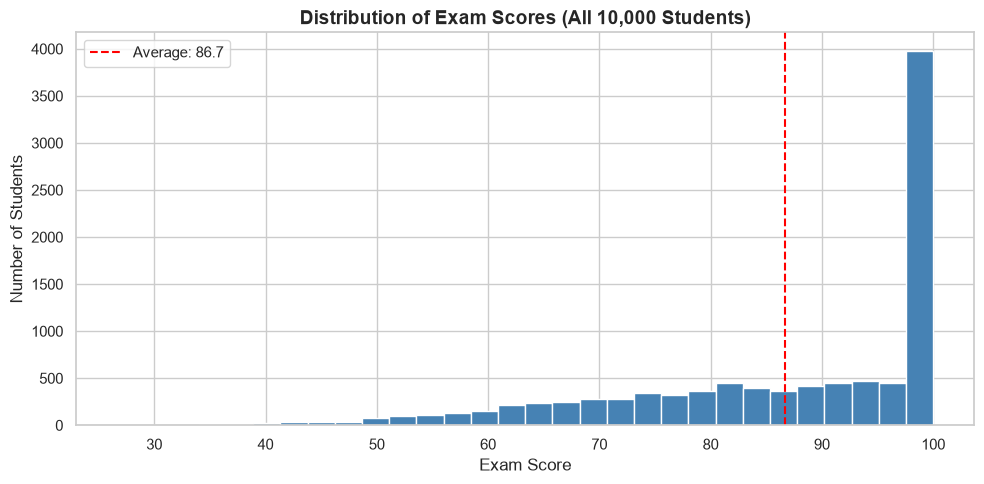


📊 Average exam score: 86.70
📊 Lowest  exam score: 26.67
📊 Highest exam score: 100.00


In [12]:
plt.figure(figsize=(10, 5))
plt.hist(df['exam_score'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Exam Scores (All 10,000 Students)', fontsize=14, fontweight='bold')
plt.xlabel('Exam Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
avg_score = df['exam_score'].mean()
plt.axvline(avg_score, color='red', linestyle='--', linewidth=1.5, label=f'Average: {avg_score:.1f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../charts/exam_score_distribution.png', dpi=150, bbox_inches='tight')  # Save the chart
plt.show()
print(f"\n📊 Average exam score: {avg_score:.2f}")
print(f"📊 Lowest  exam score: {df['exam_score'].min():.2f}")
print(f"📊 Highest exam score: {df['exam_score'].max():.2f}")

Data Cleaning

In [13]:
print("CHECK 1 — MISSING VALUES")
print("=" * 45)
missing = df.isnull().sum()
for col, count in missing.items():
    status = '✅ None' if count == 0 else f'⚠️  {count} missing'
    print(f'  {col:<28} {status}')

print()
total = missing.sum()
if total == 0:
    print('🎉 RESULT: No missing values found! Dataset is complete.')
else:
    print(f'⚠️  RESULT: {total} missing values found. Filling with column median...')

    for col in df.select_dtypes(include='number').columns:
        df[col].fillna(df[col].median(), inplace=True)

    for col in df.select_dtypes(include='object').columns:
        df[col].fillna('Unknown', inplace=True)
    print('✅ Missing values filled.')

CHECK 1 — MISSING VALUES
  study_hours                  ✅ None
  attendance                   ✅ None
  sleep_hours                  ✅ None
  internet_usage               ✅ None
  assignments_completed        ✅ None
  previous_score               ✅ None
  exam_score                   ✅ None
  placement_status             ✅ None

🎉 RESULT: No missing values found! Dataset is complete.


In [14]:
print('CHECK 2 — DUPLICATE ROWS')
print('=' * 45)
print(f'  Total rows before check : {len(df):,}')
duplicate_count = df.duplicated().sum()
print(f'  Duplicate rows found    : {duplicate_count}')

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f'  Rows after removing     : {len(df):,}')
    print('✅ Duplicates removed.')
else:
    print(f'  Rows after check        : {len(df):,}')
    print('🎉 RESULT: No duplicate rows found!')

CHECK 2 — DUPLICATE ROWS
  Total rows before check : 10,000
  Duplicate rows found    : 0
  Rows after check        : 10,000
🎉 RESULT: No duplicate rows found!


In [15]:
print('CHECK 3 — DATA TYPES')
print('=' * 55)
expected_types = {
    'study_hours'           : 'int64',
    'attendance'            : 'int64',
    'sleep_hours'           : 'int64',
    'internet_usage'        : 'int64',
    'assignments_completed' : 'int64',
    'previous_score'        : 'int64',
    'exam_score'            : 'float64',
    'placement_status'      : 'object',
}

print(f"  {'COLUMN':<28} {'ACTUAL TYPE':<12} {'EXPECTED':<12} STATUS")
print('  ' + '-' * 60)

for col, expected in expected_types.items():
    actual = str(df[col].dtype)
    ok = (actual == expected) or (expected == 'object' and 'str' in actual.lower())
    status = '✅' if ok else '⚠️  MISMATCH'
    print(f"  {col:<28} {actual:<12} {expected:<12} {status}")

print()
print('🎉 RESULT: All data types are correct!')

CHECK 3 — DATA TYPES
  COLUMN                       ACTUAL TYPE  EXPECTED     STATUS
  ------------------------------------------------------------
  study_hours                  int64        int64        ✅
  attendance                   int64        int64        ✅
  sleep_hours                  int64        int64        ✅
  internet_usage               int64        int64        ✅
  assignments_completed        int64        int64        ✅
  previous_score               int64        int64        ✅
  exam_score                   float64      float64      ✅
  placement_status             str          object       ✅

🎉 RESULT: All data types are correct!


In [16]:
print('CHECK 4 — IMPOSSIBLE / OUT-OF-RANGE VALUES')
print('=' * 60)
valid_ranges = {
    'study_hours'           : (0, 24),
    'attendance'            : (0, 100),
    'sleep_hours'           : (0, 24),
    'internet_usage'        : (0, 24),
    'assignments_completed' : (0, 50),
    'previous_score'        : (0, 100),
    'exam_score'            : (0, 100),
}

print(f"  {'COLUMN':<28} {'MIN IN DATA':>12} {'MAX IN DATA':>12} {'ALLOWED RANGE':<16} STATUS")
print('  ' + '-' * 80)

all_clean = True
for col, (lo, hi) in valid_ranges.items():
    col_min = df[col].min()
    col_max = df[col].max()
    bad_count = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    status = '✅' if bad_count == 0 else f'⚠️  {bad_count} bad values'
    if bad_count > 0:
        all_clean = False
    print(f"  {col:<28} {col_min:>12.1f} {col_max:>12.1f} {str(lo)+'-'+str(hi):<16} {status}")

print()
if all_clean:
    print('🎉 RESULT: All values are within valid ranges!')
else:
    print('⚠️  Some out-of-range values found. Review before analysis.')

CHECK 4 — IMPOSSIBLE / OUT-OF-RANGE VALUES
  COLUMN                        MIN IN DATA  MAX IN DATA ALLOWED RANGE    STATUS
  --------------------------------------------------------------------------------
  study_hours                           1.0         11.0 0-24             ✅
  attendance                           40.0        100.0 0-100            ✅
  sleep_hours                           4.0          9.0 0-24             ✅
  internet_usage                        1.0         11.0 0-24             ✅
  assignments_completed                 0.0         20.0 0-50             ✅
  previous_score                       35.0         95.0 0-100            ✅
  exam_score                           26.7        100.0 0-100            ✅

🎉 RESULT: All values are within valid ranges!


In [17]:
print('CHECK 5 — WHITESPACE & TYPOS IN TEXT COLUMNS')
print('=' * 50)

text_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'  Text columns found: {text_cols}')
print()

for col in text_cols:

    whitespace_issues = df[col].str.strip().ne(df[col]).sum()
    print(f'  {col}:')
    print(f'    Unique values before cleaning : {df[col].unique()}')
    print(f'    Whitespace issues found       : {whitespace_issues}')

    df[col] = df[col].str.strip()

    print(f'    Unique values after cleaning  : {df[col].unique()}')
    print(f'    Value counts after cleaning   :')
    for val, cnt in df[col].value_counts().items():
        print(f'      {val}: {cnt:,}')
    print()

print('✅ RESULT: Text columns are clean — no whitespace or typo issues!')

CHECK 5 — WHITESPACE & TYPOS IN TEXT COLUMNS
  Text columns found: ['placement_status']

  placement_status:
    Unique values before cleaning : <StringArray>
['Placed', 'Not Placed']
Length: 2, dtype: str
    Whitespace issues found       : 0
    Unique values after cleaning  : <StringArray>
['Placed', 'Not Placed']
Length: 2, dtype: str
    Value counts after cleaning   :
      Placed: 8,356
      Not Placed: 1,644

✅ RESULT: Text columns are clean — no whitespace or typo issues!


In [18]:
print('CHECK 6 — COLUMN NAMES')
print('=' * 50)

print('  Column names before standardising:')
for col in df.columns:
    print(f'    → {col}')

df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

print()
print('  Column names after standardising:')
for col in df.columns:
    print(f'    ✅ {col}')

print()
print('🎉 RESULT: All column names are clean and standardised!')

CHECK 6 — COLUMN NAMES
  Column names before standardising:
    → study_hours
    → attendance
    → sleep_hours
    → internet_usage
    → assignments_completed
    → previous_score
    → exam_score
    → placement_status

  Column names after standardising:
    ✅ study_hours
    ✅ attendance
    ✅ sleep_hours
    ✅ internet_usage
    ✅ assignments_completed
    ✅ previous_score
    ✅ exam_score
    ✅ placement_status

🎉 RESULT: All column names are clean and standardised!


In [19]:
df.to_csv('../data/student_dataset_cleaned.csv', index=False)

print('✅ Cleaned dataset saved as: student_dataset_cleaned.csv')
print()
print(f'  Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('  Preview of cleaned dataset:')

✅ Cleaned dataset saved as: student_dataset_cleaned.csv

  Final shape: 10,000 rows × 8 columns

  Preview of cleaned dataset:


In [20]:
print('=' * 55)
print('        DATA CLEANING REPORT')
print('=' * 55)
print(f'  Dataset  : Student Performance Dataset')
print(f'  Rows     : {df.shape[0]:,}')
print(f'  Columns  : {df.shape[1]}')
print()
print('  CHECK RESULTS:')
print('  ✅ Check 1 — Missing values    : None found')
print('  ✅ Check 2 — Duplicate rows    : None found')
print('  ✅ Check 3 — Data types        : All correct')
print('  ✅ Check 4 — Value ranges      : All within valid limits')
print('  ✅ Check 5 — Text whitespace   : Stripped and verified')
print('  ✅ Check 6 — Column names      : Standardised (lowercase + underscores)')
print()
print('  CONCLUSION: Dataset is clean. No values were modified.')
print('  Cleaned file saved as: student_dataset_cleaned.csv')
print('=' * 55)

        DATA CLEANING REPORT
  Dataset  : Student Performance Dataset
  Rows     : 10,000
  Columns  : 8

  CHECK RESULTS:
  ✅ Check 1 — Missing values    : None found
  ✅ Check 2 — Duplicate rows    : None found
  ✅ Check 3 — Data types        : All correct
  ✅ Check 4 — Value ranges      : All within valid limits
  ✅ Check 5 — Text whitespace   : Stripped and verified
  ✅ Check 6 — Column names      : Standardised (lowercase + underscores)

  CONCLUSION: Dataset is clean. No values were modified.
  Cleaned file saved as: student_dataset_cleaned.csv


Descriptive Statistics

In [21]:
numeric_cols = ['study_hours', 'attendance', 'sleep_hours',
                'internet_usage', 'assignments_completed',
                'previous_score', 'exam_score']
stats = df[numeric_cols].describe().round(2)

print('MASTER STATISTICS TABLE')
print('(count=rows, std=standard deviation, 50%=median)')
print()
stats

MASTER STATISTICS TABLE
(count=rows, std=standard deviation, 50%=median)



,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5.99,69.88,6.50,6.06,9.99,64.91,86.70
std,3.16,17.62,1.71,3.14,6.03,17.50,15.06
min,1.00,40.00,4.00,1.00,0.00,35.00,26.67
25%,3.00,55.00,5.00,3.00,5.00,50.00,76.73
50%,6.00,70.00,6.50,6.00,10.00,65.00,92.12
75%,9.00,85.00,8.00,9.00,15.00,80.00,100.00
max,11.00,100.00,9.00,11.00,20.00,95.00,100.00


In [22]:
print(f"{'COLUMN':<28} {'MEAN':>8} {'MEDIAN':>8} {'MODE':>8}  INTERPRETATION")
print('-' * 80)

for col in numeric_cols:
    mean   = df[col].mean()
    median = df[col].median()
    mode   = df[col].mode()[0]

    diff = mean - median
    if abs(diff) < 1:
        note = 'Balanced distribution'
    elif diff < 0:
        note = 'Mean pulled DOWN by low scorers'
    else:
        note = 'Mean pulled UP by high scorers'

    print(f"{col:<28} {mean:>8.2f} {median:>8.2f} {mode:>8.1f}  {note}")

print()
print('💡 KEY INSIGHT: exam_score has mean=86.70 but median=92.12')
print('   → Most students score HIGH (around 92), but a small group of')
print('     very low scorers pulls the average down to 86.70.')

COLUMN                           MEAN   MEDIAN     MODE  INTERPRETATION
--------------------------------------------------------------------------------
study_hours                      5.99     6.00     10.0  Balanced distribution
attendance                      69.88    70.00     56.0  Balanced distribution
sleep_hours                      6.50     6.50      5.0  Balanced distribution
internet_usage                   6.06     6.00      5.0  Balanced distribution
assignments_completed            9.99    10.00      5.0  Balanced distribution
previous_score                  64.91    65.00     57.0  Balanced distribution
exam_score                      86.70    92.12    100.0  Mean pulled DOWN by low scorers

💡 KEY INSIGHT: exam_score has mean=86.70 but median=92.12
   → Most students score HIGH (around 92), but a small group of
     very low scorers pulls the average down to 86.70.


In [23]:
print(f"{'COLUMN':<28} {'STD DEV':>10} {'VARIANCE':>10}  SPREAD")
print('-' * 65)

for col in numeric_cols:
    std = df[col].std()
    var = df[col].var()
    cv = (std / df[col].mean()) * 100
    spread = 'High variation' if cv > 40 else ('Moderate' if cv > 20 else 'Low variation')

    print(f"{col:<28} {std:>10.2f} {var:>10.2f}  {spread} (CV={cv:.1f}%)")

print()
print('💡 attendance and previous_score have the highest variance')
print('   → Students differ the most on these two metrics.')
print('   sleep_hours has the lowest variance → most students sleep similarly.')

COLUMN                          STD DEV   VARIANCE  SPREAD
-----------------------------------------------------------------
study_hours                        3.16      10.01  High variation (CV=52.8%)
attendance                        17.62     310.34  Moderate (CV=25.2%)
sleep_hours                        1.71       2.92  Moderate (CV=26.3%)
internet_usage                     3.14       9.85  High variation (CV=51.8%)
assignments_completed              6.03      36.41  High variation (CV=60.4%)
previous_score                    17.50     306.36  Moderate (CV=27.0%)
exam_score                        15.06     226.75  Low variation (CV=17.4%)

💡 attendance and previous_score have the highest variance
   → Students differ the most on these two metrics.
   sleep_hours has the lowest variance → most students sleep similarly.


In [24]:
print(f"{'COLUMN':<28} {'SKEWNESS':>10}  SHAPE")
print('-' * 65)

for col in numeric_cols:
    sk = df[col].skew()

    if sk < -0.5:
        shape = f'Left-skewed  → most values HIGH, few very low'
    elif sk > 0.5:
        shape = f'Right-skewed → most values LOW, few very high'
    else:
        shape = f'Symmetric    → values evenly spread around mean'

    print(f"{col:<28} {sk:>10.3f}  {shape}")

print()
print('💡 Only exam_score is skewed (skew = -1.009)')
print('   All other columns are beautifully symmetric — rare in real data!')

COLUMN                         SKEWNESS  SHAPE
-----------------------------------------------------------------
study_hours                      -0.007  Symmetric    → values evenly spread around mean
attendance                        0.018  Symmetric    → values evenly spread around mean
sleep_hours                       0.005  Symmetric    → values evenly spread around mean
internet_usage                   -0.013  Symmetric    → values evenly spread around mean
assignments_completed             0.018  Symmetric    → values evenly spread around mean
previous_score                    0.000  Symmetric    → values evenly spread around mean
exam_score                       -1.009  Left-skewed  → most values HIGH, few very low

💡 Only exam_score is skewed (skew = -1.009)
   All other columns are beautifully symmetric — rare in real data!


In [25]:
print(f"{'COLUMN':<28} {'Q1':>8} {'Q2':>8} {'Q3':>8} {'IQR':>8}")
print('-' * 65)

for col in numeric_cols:
    q1  = df[col].quantile(0.25)
    q2  = df[col].quantile(0.50)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    print(f"{col:<28} {q1:>8.2f} {q2:>8.2f} {q3:>8.2f} {iqr:>8.2f}")

print()
print('💡 exam_score: Q1=76.73, Q3=100.00 → the TOP 25% of students all scored 100!')
print('   study_hours: IQR=6 → the middle 50% of students study between 3 and 9 hrs.')

COLUMN                             Q1       Q2       Q3      IQR
-----------------------------------------------------------------
study_hours                      3.00     6.00     9.00     6.00
attendance                      55.00    70.00    85.00    30.00
sleep_hours                      5.00     6.50     8.00     3.00
internet_usage                   3.00     6.00     9.00     6.00
assignments_completed            5.00    10.00    15.00    10.00
previous_score                  50.00    65.00    80.00    30.00
exam_score                      76.73    92.12   100.00    23.27

💡 exam_score: Q1=76.73, Q3=100.00 → the TOP 25% of students all scored 100!
   study_hours: IQR=6 → the middle 50% of students study between 3 and 9 hrs.


In [26]:
placed     = df[df['placement_status'] == 'Placed']
not_placed = df[df['placement_status'] == 'Not Placed']

print(f'Students Placed     : {len(placed):,} ({len(placed)/len(df)*100:.1f}%)')
print(f'Students Not Placed : {len(not_placed):,} ({len(not_placed)/len(df)*100:.1f}%)')
print()

print(f"{'COLUMN':<28} {'PLACED':>10} {'NOT PLACED':>12} {'DIFFERENCE':>12}")
print('-' * 68)

for col in numeric_cols:
    p_mean  = placed[col].mean()
    np_mean = not_placed[col].mean()
    diff    = p_mean - np_mean
    arrow   = '↑ higher' if diff > 0 else '↓ lower'
    print(f"{col:<28} {p_mean:>10.2f} {np_mean:>12.2f} {diff:>+10.2f}  {arrow}")

print()
print('💡 Placed students have HIGHER: study hours, attendance, sleep, assignments, scores')
print('   Placed students have LOWER : internet usage (-0.93 hrs less per day)')

Students Placed     : 8,356 (83.6%)
Students Not Placed : 1,644 (16.4%)

COLUMN                           PLACED   NOT PLACED   DIFFERENCE
--------------------------------------------------------------------
study_hours                        6.55         3.13      +3.42  ↑ higher
attendance                        71.27        62.87      +8.40  ↑ higher
sleep_hours                        6.58         6.07      +0.51  ↑ higher
internet_usage                     5.91         6.84      -0.93  ↓ lower
assignments_completed             10.74         6.18      +4.56  ↑ higher
previous_score                    66.72        55.73     +10.99  ↑ higher
exam_score                        92.00        59.80     +32.19  ↑ higher

💡 Placed students have HIGHER: study hours, attendance, sleep, assignments, scores
   Placed students have LOWER : internet usage (-0.93 hrs less per day)


In [27]:
corr = df[numeric_cols].corr()['exam_score'].drop('exam_score').sort_values(ascending=False)

print('CORRELATION WITH EXAM SCORE (strongest → weakest)')
print('-' * 60)

for col, r in corr.items():
    bar_len  = int(abs(r) * 30)
    bar      = '█' * bar_len
    strength = 'Strong' if abs(r) > 0.5 else ('Moderate' if abs(r) > 0.3 else 'Weak')
    sign     = '+' if r > 0 else '-'
    print(f"  {col:<28} r={r:+.3f}  {bar:<30} {strength}")

print()
print(f'💡 STRONGEST link  : study_hours       (r=+0.563) — more study = higher score')
print(f'💡 ONLY negative   : internet_usage    (r=-0.152) — more internet = lower score')
print(f'💡 WEAKEST link    : sleep_hours       (r=+0.145) — sleep has small effect')

CORRELATION WITH EXAM SCORE (strongest → weakest)
------------------------------------------------------------
  study_hours                  r=+0.563  ████████████████               Strong
  assignments_completed        r=+0.388  ███████████                    Moderate
  previous_score               r=+0.319  █████████                      Moderate
  attendance                   r=+0.223  ██████                         Weak
  sleep_hours                  r=+0.145  ████                           Weak
  internet_usage               r=-0.152  ████                           Weak

💡 STRONGEST link  : study_hours       (r=+0.563) — more study = higher score
💡 ONLY negative   : internet_usage    (r=-0.152) — more internet = lower score
💡 WEAKEST link    : sleep_hours       (r=+0.145) — sleep has small effect


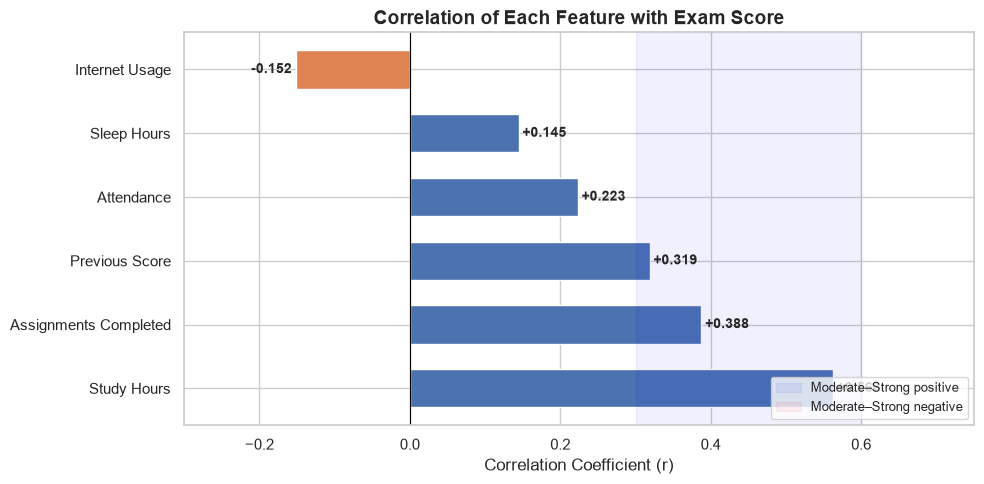

✅ Correlation chart saved!


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0' if r > 0 else '#DD8452' for r in corr.values]
labels = [c.replace('_', ' ').title() for c in corr.index]

bars = ax.barh(labels, corr.values, color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, corr.values):
    xpos = bar.get_width() + 0.005 if val > 0 else bar.get_width() - 0.005
    ha   = 'left' if val > 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=10, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvspan( 0.3,  0.6, alpha=0.06, color='blue',  label='Moderate–Strong positive')
ax.axvspan(-0.3, -0.6, alpha=0.06, color='red',   label='Moderate–Strong negative')

ax.set_xlabel('Correlation Coefficient (r)', fontsize=12)
ax.set_title('Correlation of Each Feature with Exam Score', fontsize=14, fontweight='bold')
ax.set_xlim(-0.3, 0.75)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('../charts/correlation_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation chart saved!')

In [29]:
print('=' * 60)
print('       DESCRIPTIVE STATISTICS REPORT')
print('       Student Performance Dataset — 10,000 rows')
print('=' * 60)
print()
print('1. DATASET OVERVIEW')
print(f'   Total students    : {len(df):,}')
print(f'   Placed            : {len(placed):,} ({len(placed)/len(df)*100:.1f}%)')
print(f'   Not Placed        : {len(not_placed):,} ({len(not_placed)/len(df)*100:.1f}%)')
print()
print('2. KEY AVERAGES (All Students)')
for col in numeric_cols:
    print(f'   {col:<28}: mean={df[col].mean():.2f}, median={df[col].median():.2f}')
print()
print('3. BIGGEST DIFFERENCES (Placed vs Not Placed)')
diffs = [(col,
          placed[col].mean() - not_placed[col].mean())
         for col in numeric_cols]
diffs.sort(key=lambda x: abs(x[1]), reverse=True)
for col, d in diffs:
    direction = 'HIGHER' if d > 0 else 'LOWER'
    print(f'   {col:<28}: Placed score {abs(d):.2f} {direction}')
print()
print('4. STRONGEST PREDICTORS OF EXAM SCORE')
for col, r in corr.items():
    strength = 'Strong' if abs(r)>0.5 else ('Moderate' if abs(r)>0.3 else 'Weak')
    print(f'   {col:<28}: r={r:+.3f} ({strength})')
print()
print('=' * 60)

       DESCRIPTIVE STATISTICS REPORT
       Student Performance Dataset — 10,000 rows

1. DATASET OVERVIEW
   Total students    : 10,000
   Placed            : 8,356 (83.6%)
   Not Placed        : 1,644 (16.4%)

2. KEY AVERAGES (All Students)
   study_hours                 : mean=5.99, median=6.00
   attendance                  : mean=69.88, median=70.00
   sleep_hours                 : mean=6.50, median=6.50
   internet_usage              : mean=6.06, median=6.00
   assignments_completed       : mean=9.99, median=10.00
   previous_score              : mean=64.91, median=65.00
   exam_score                  : mean=86.70, median=92.12

3. BIGGEST DIFFERENCES (Placed vs Not Placed)
   exam_score                  : Placed score 32.19 HIGHER
   previous_score              : Placed score 10.99 HIGHER
   attendance                  : Placed score 8.40 HIGHER
   assignments_completed       : Placed score 4.56 HIGHER
   study_hours                 : Placed score 3.42 HIGHER
   internet_usage  

Visual Analysis

In [30]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi']      = 120
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']   = 13
PALETTE   = {'Placed': '#4C72B0', 'Not Placed': '#DD8452'}
BAR_COLOR = '#4C72B0'

numeric_cols = ['study_hours', 'attendance', 'sleep_hours',
                'internet_usage', 'assignments_completed',
                'previous_score', 'exam_score']

print('✅ Chart setup complete! Ready to draw.')

✅ Chart setup complete! Ready to draw.


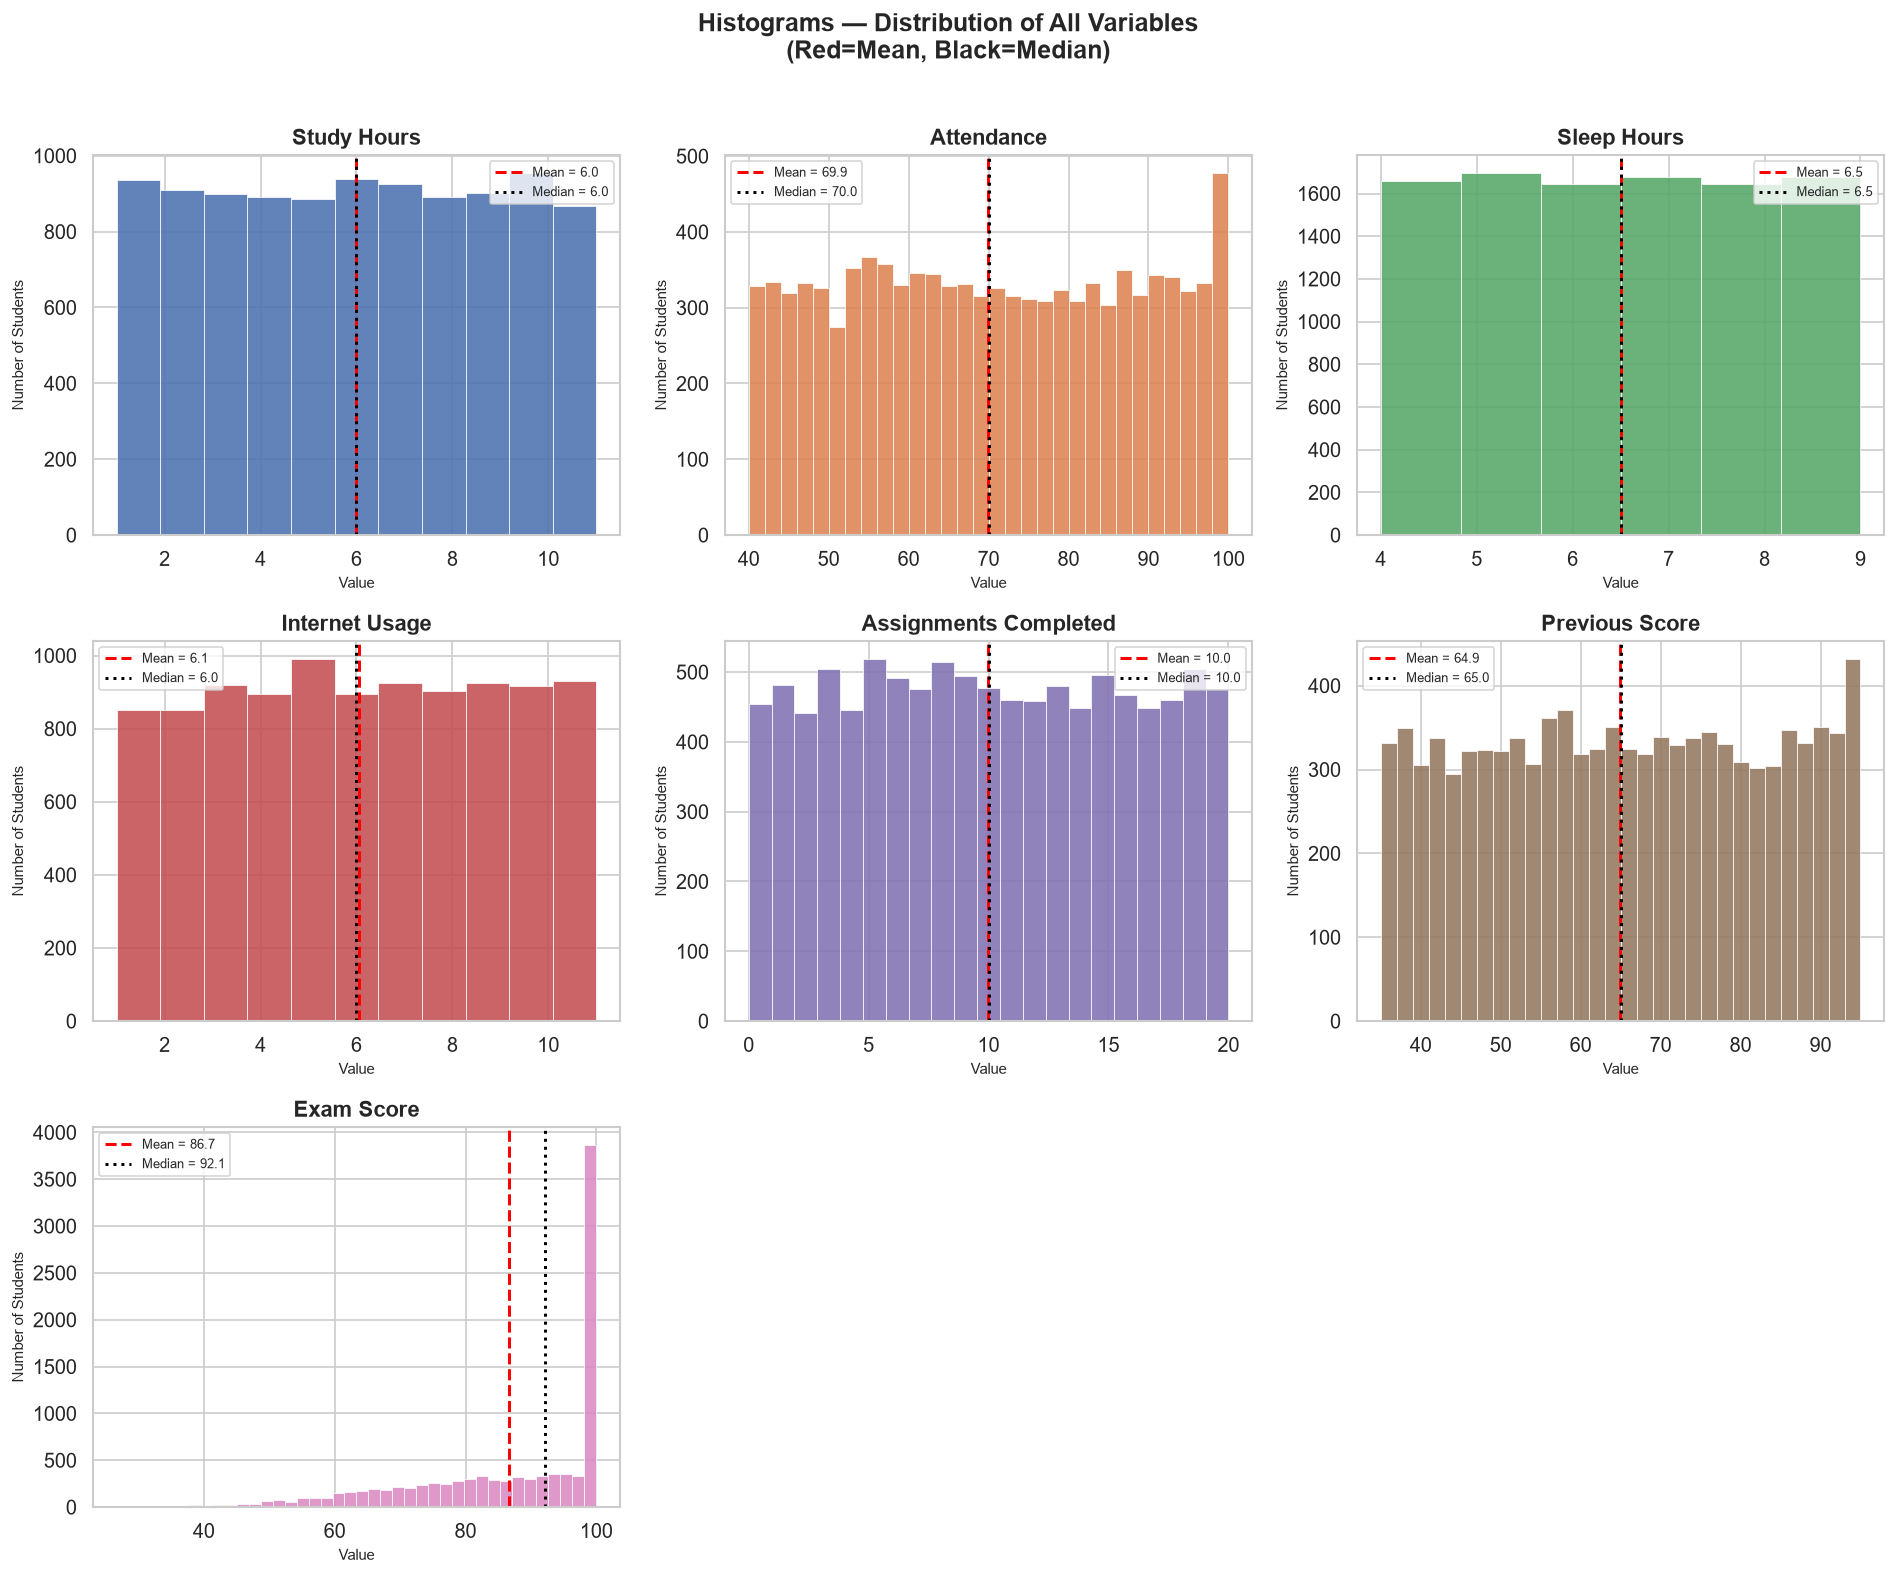

✅ Histograms saved as chart_01_histograms.png

💡 What to notice:
   → study_hours, attendance, internet_usage: uniform spread (flat bars) — students are evenly distributed
   → exam_score: LEFT-skewed (most students score HIGH, few score very low)
   → sleep_hours: concentrated around 5-7 hours (most students sleep similarly)


In [31]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3']
bin_counts = {
    'study_hours': 11,
    'attendance': 30,
    'sleep_hours': 6,
    'internet_usage': 11,
    'assignments_completed': 21,
    'previous_score': 30,
    'exam_score': 40
}

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    bins = bin_counts[col]


    ax.hist(df[col], bins=bins, color=colors[i], edgecolor='white',
            alpha=0.88, linewidth=0.5)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--',
               linewidth=1.8, label=f'Mean = {mean_val:.1f}')
    median_val = df[col].median()
    ax.axvline(median_val, color='black', linestyle=':',
               linewidth=1.8, label=f'Median = {median_val:.1f}')

    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Number of Students', fontsize=9)
    ax.legend(fontsize=8)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histograms — Distribution of All Variables\n(Red=Mean, Black=Median)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../charts/chart_01_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Histograms saved as chart_01_histograms.png')
print()
print('💡 What to notice:')
print('   → study_hours, attendance, internet_usage: uniform spread (flat bars) — students are evenly distributed')
print('   → exam_score: LEFT-skewed (most students score HIGH, few score very low)')
print('   → sleep_hours: concentrated around 5-7 hours (most students sleep similarly)')

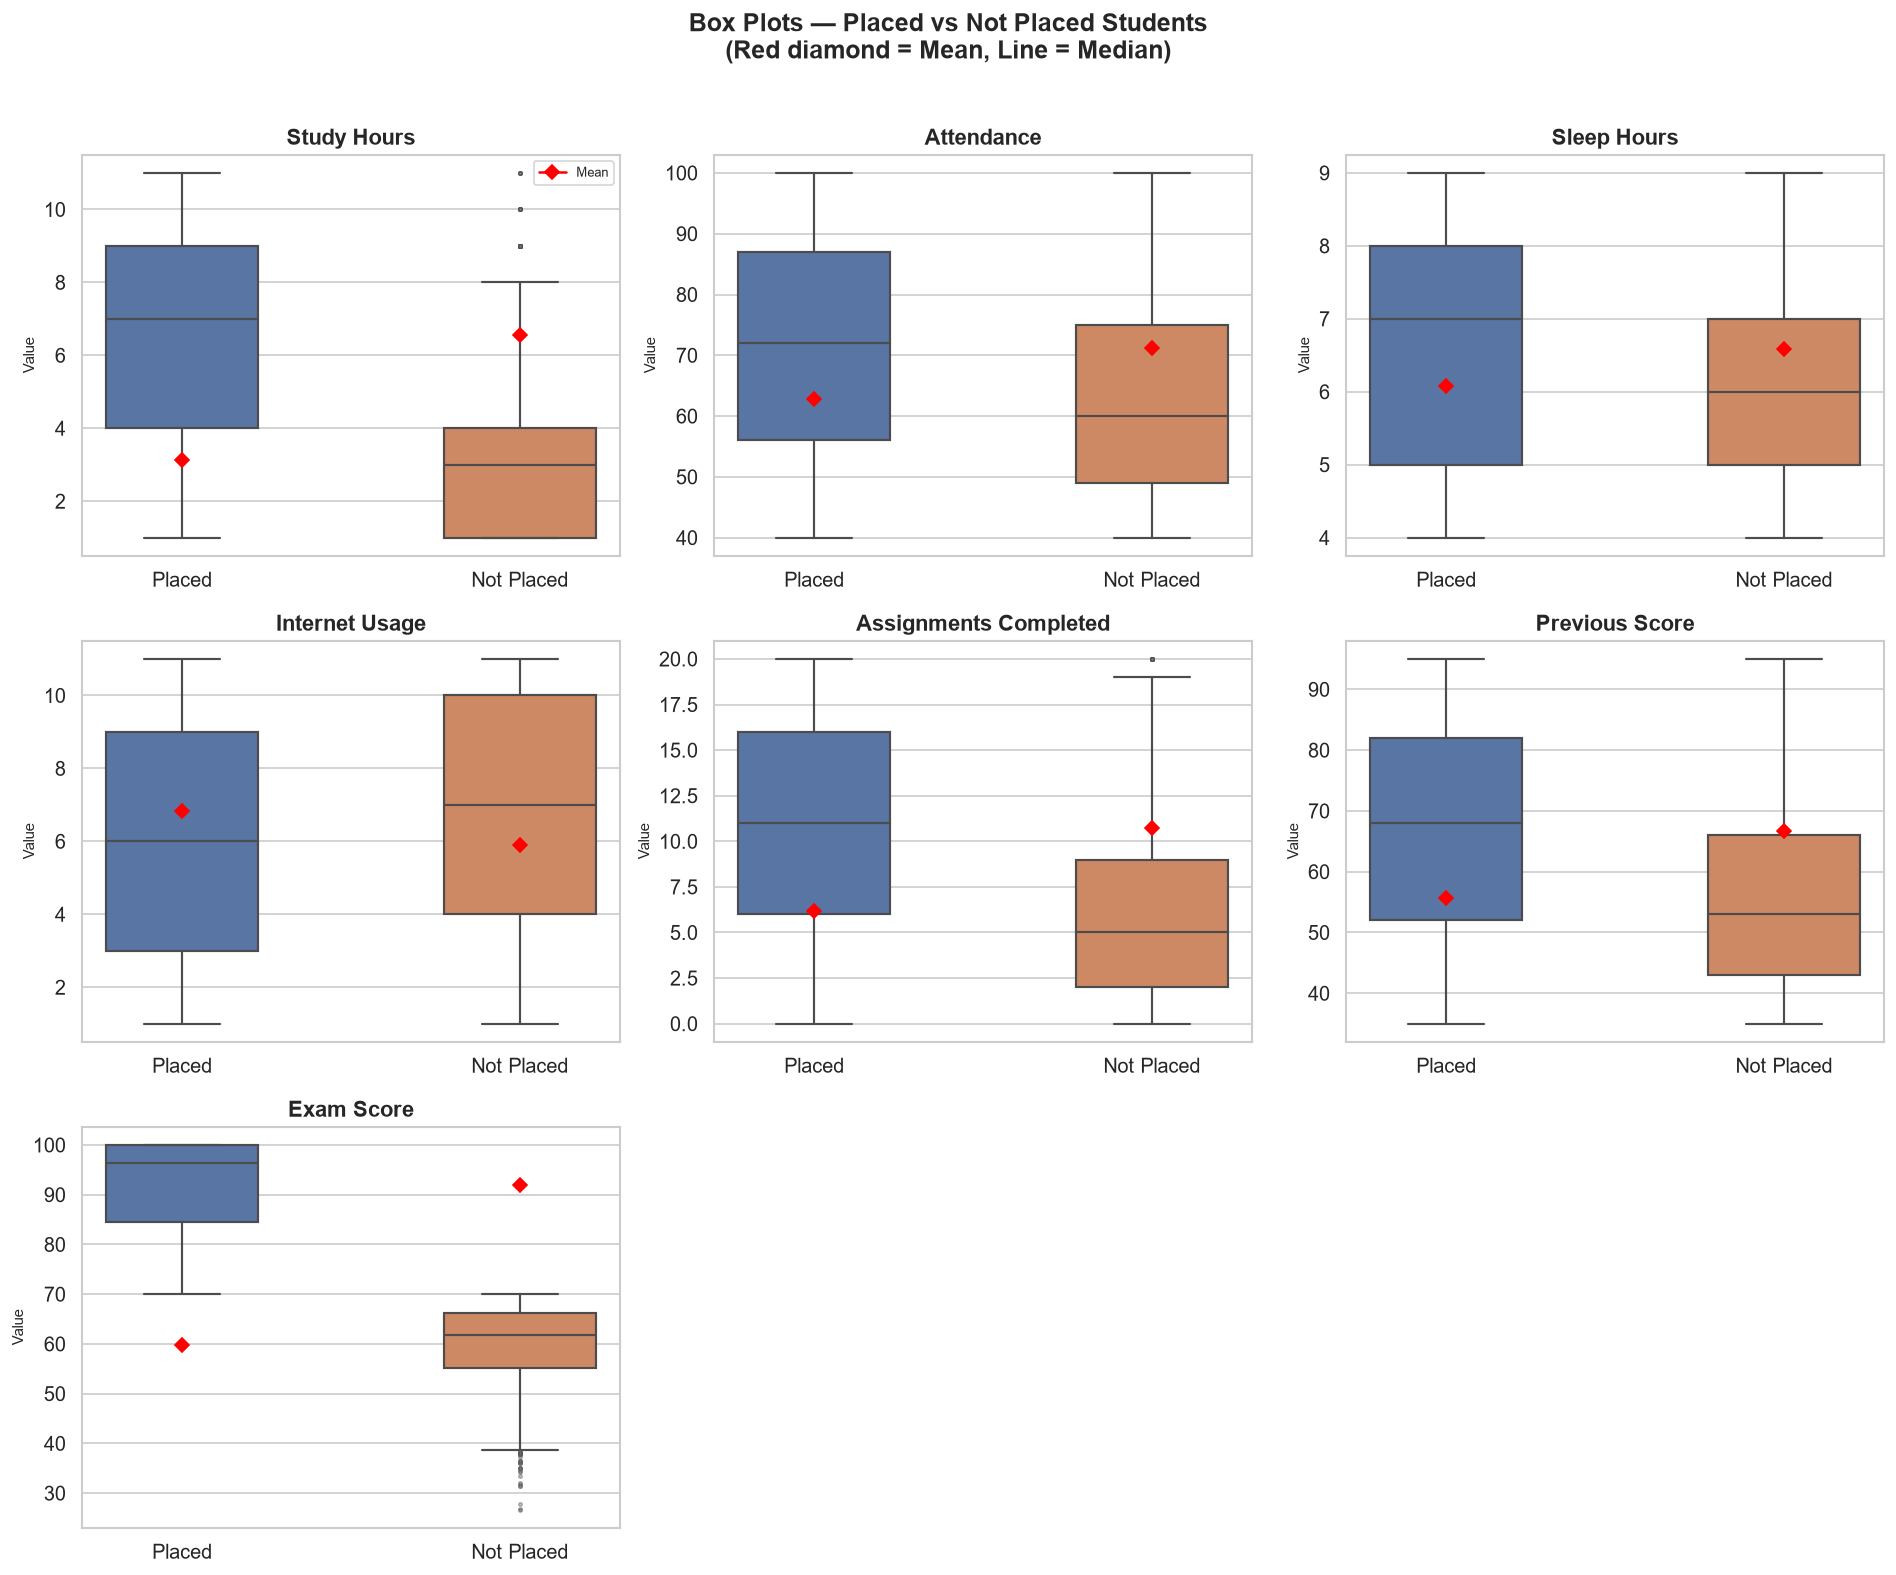

✅ Box plots saved as chart_02_boxplots.png


In [32]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    sns.boxplot(
        data=df,
        x='placement_status',
        y=col,
        hue='placement_status',      # ← added
        palette=PALETTE,
        legend=False,                 # ← added
        ax=ax,
        width=0.45,
        linewidth=1.3,
        flierprops=dict(marker='o', markerfacecolor='grey',
                        markersize=2, alpha=0.4)
    )

    means = df.groupby('placement_status')[col].mean()
    for j, (status, mean_val) in enumerate(means.items()):
        ax.plot(j, mean_val, marker='D', color='red',
                markersize=6, zorder=5, label='Mean' if j == 0 else '')

    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Value', fontsize=9)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Box Plots — Placed vs Not Placed Students\n(Red diamond = Mean, Line = Median)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../charts/chart_02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Box plots saved as chart_02_boxplots.png')

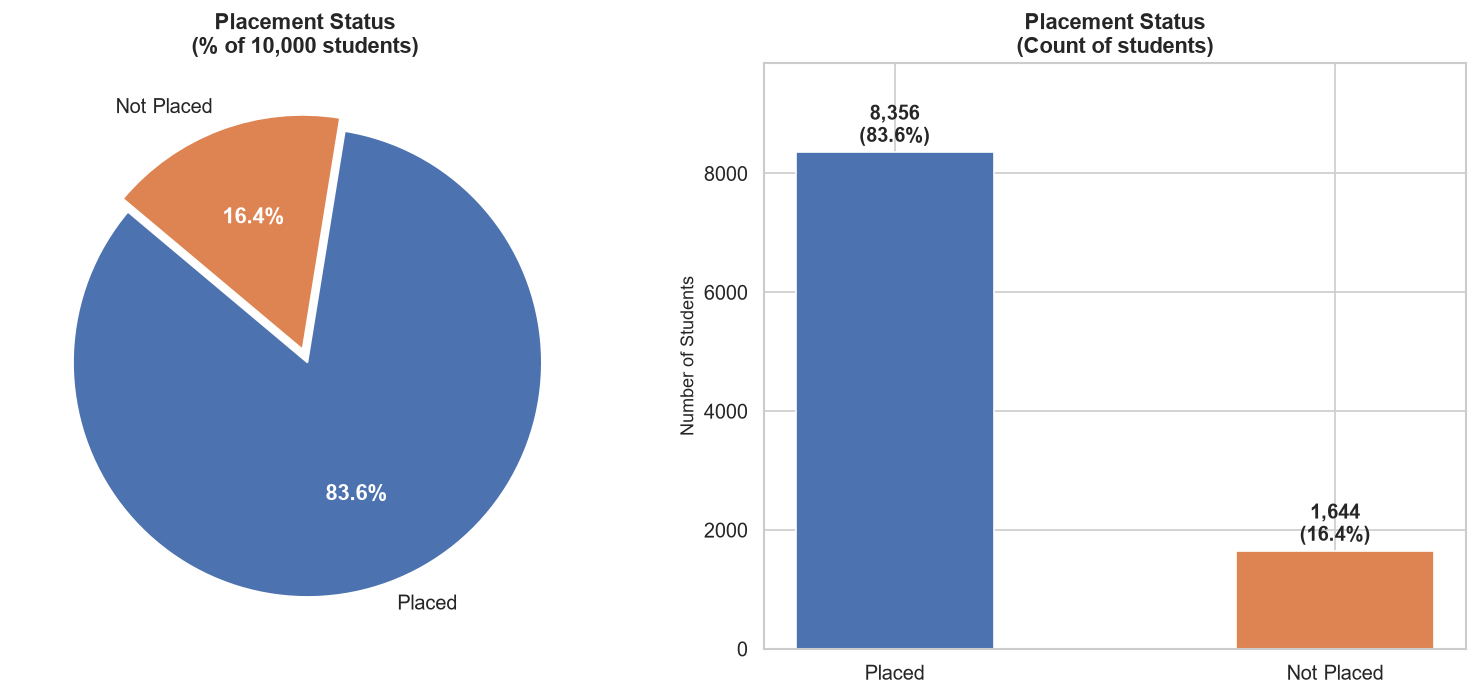

✅ Placement chart saved as chart_03_placement_pie.png

   Placed     : 8,356 students (83.6%)
   Not Placed : 1,644 students (16.4%)


In [33]:
counts = df['placement_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))


ax1 = axes[0]
wedge_colors = ['#4C72B0', '#DD8452']
explode = (0.03, 0.03)

wedges, texts, autotexts = ax1.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

ax1.set_title('Placement Status\n(% of 10,000 students)', fontsize=13, fontweight='bold')
ax2 = axes[1]
bars = ax2.bar(counts.index, counts.values,
               color=wedge_colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 80,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_title('Placement Status\n(Count of students)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Students', fontsize=11)
ax2.set_ylim(0, counts.max() * 1.18)

plt.tight_layout()
plt.savefig('../charts/chart_03_placement_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Placement chart saved as chart_03_placement_pie.png')
print(f'\n   Placed     : {counts["Placed"]:,} students (83.6%)')
print(f'   Not Placed : {counts["Not Placed"]:,} students (16.4%)')

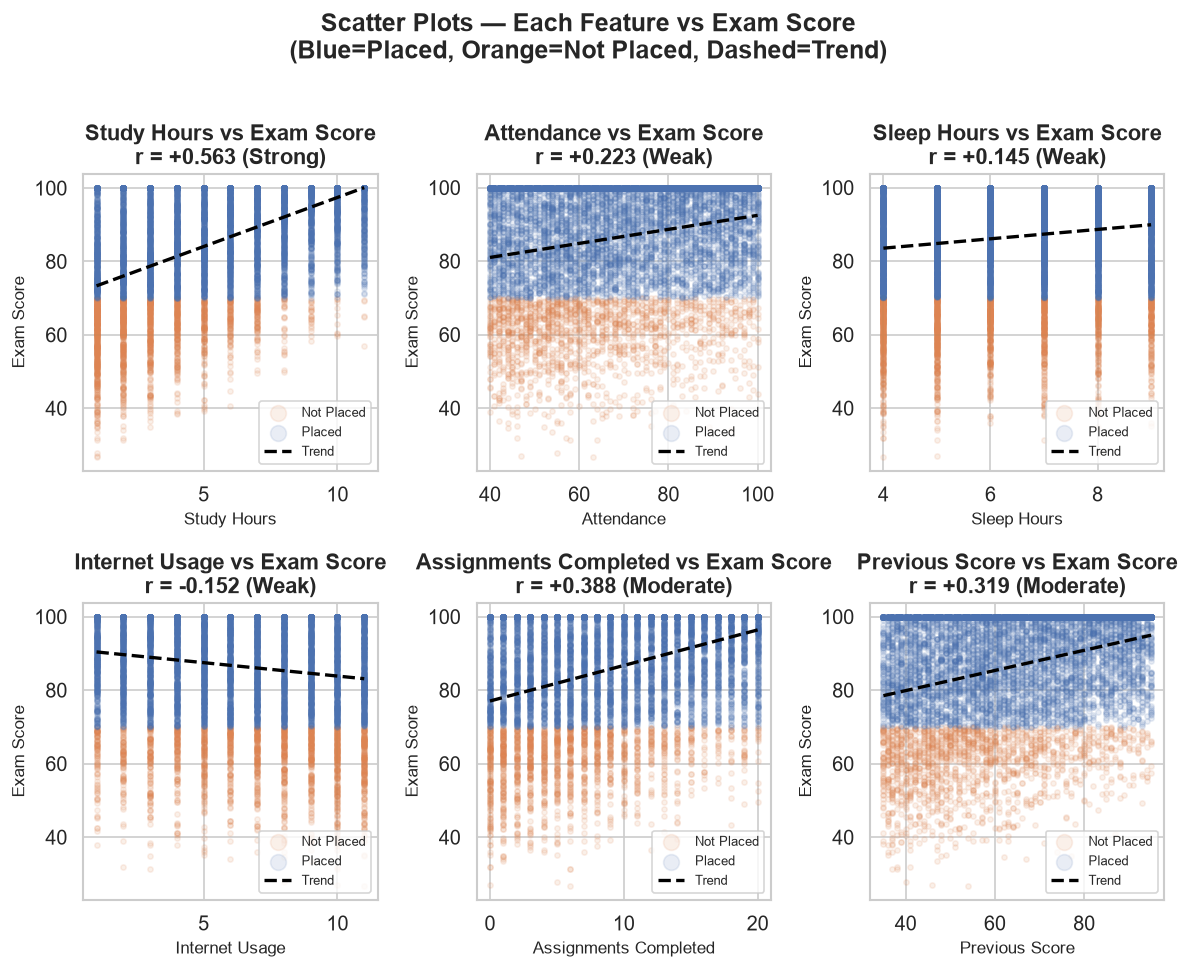

✅ Scatter plots saved as chart_04_scatter_plots.png

💡 What to notice:
   → study_hours vs exam_score: clear upward trend (r=+0.563)
     Blue dots cluster TOP-RIGHT, orange dots cluster BOTTOM-LEFT
   → internet_usage vs exam_score: slight downward trend (r=-0.152)
   → sleep_hours vs exam_score: very scattered, weak relationship (r=+0.145)


In [34]:
compare_cols = ['study_hours', 'attendance', 'sleep_hours',
                'internet_usage', 'assignments_completed', 'previous_score']

fig, axes = plt.subplots(2, 3, figsize=(10,8))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    ax = axes[i]
    for status, grp in df.groupby('placement_status'):
        ax.scatter(
            grp[col],
            grp['exam_score'],
            color=PALETTE[status],
            alpha=0.12,
            s=10,
            label=status
        )

    z = np.polyfit(df[col], df['exam_score'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, p(x_range),
            color='black', linewidth=2, linestyle='--', label='Trend')


    r = df[col].corr(df['exam_score'])
    strength = 'Strong' if abs(r) > 0.5 else ('Moderate' if abs(r) > 0.3 else 'Weak')

    ax.set_title(f'{col.replace("_"," ").title()} vs Exam Score\nr = {r:+.3f} ({strength})')
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Exam Score', fontsize=10)
    ax.legend(fontsize=8, markerscale=3, loc='lower right')

fig.suptitle('Scatter Plots — Each Feature vs Exam Score\n(Blue=Placed, Orange=Not Placed, Dashed=Trend)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../charts/chart_04_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Scatter plots saved as chart_04_scatter_plots.png')
print()
print('💡 What to notice:')
print('   → study_hours vs exam_score: clear upward trend (r=+0.563)')
print('     Blue dots cluster TOP-RIGHT, orange dots cluster BOTTOM-LEFT')
print('   → internet_usage vs exam_score: slight downward trend (r=-0.152)')
print('   → sleep_hours vs exam_score: very scattered, weak relationship (r=+0.145)')

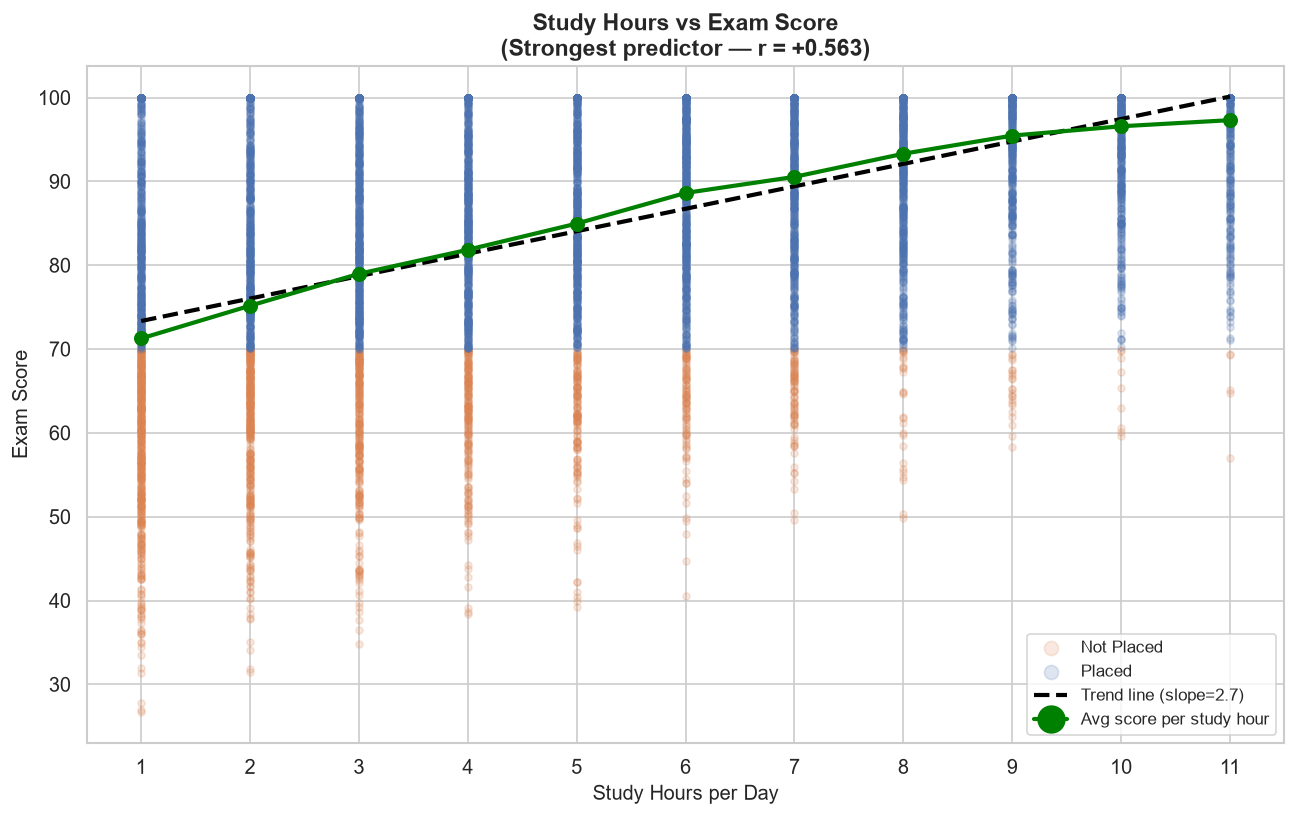

✅ Detailed scatter saved as chart_05_study_vs_score_detail.png

Average exam score for each study hour level:
----------------------------------------
   1 hrs/day → avg score = 71.3  ██████████████
   2 hrs/day → avg score = 75.2  ███████████████
   3 hrs/day → avg score = 79.0  ███████████████
   4 hrs/day → avg score = 81.8  ████████████████
   5 hrs/day → avg score = 85.0  ████████████████
   6 hrs/day → avg score = 88.6  █████████████████
   7 hrs/day → avg score = 90.5  ██████████████████
   8 hrs/day → avg score = 93.3  ██████████████████
   9 hrs/day → avg score = 95.5  ███████████████████
  10 hrs/day → avg score = 96.6  ███████████████████
  11 hrs/day → avg score = 97.3  ███████████████████


In [35]:
fig, ax = plt.subplots(figsize=(11, 7))

for status, grp in df.groupby('placement_status'):
    ax.scatter(grp['study_hours'], grp['exam_score'],
               color=PALETTE[status], alpha=0.18, s=18, label=status)
z = np.polyfit(df['study_hours'], df['exam_score'], 1)
p = np.poly1d(z)
x_range = np.linspace(1, 11, 100)
ax.plot(x_range, p(x_range), color='black', linewidth=2.5,
        linestyle='--', label=f'Trend line (slope={z[0]:.1f})')
avg_by_study = df.groupby('study_hours')['exam_score'].mean()
ax.plot(avg_by_study.index, avg_by_study.values,
        color='green', linewidth=2.5, marker='o',
        markersize=8, label='Avg score per study hour')

ax.set_title('Study Hours vs Exam Score\n(Strongest predictor — r = +0.563)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Study Hours per Day', fontsize=12)
ax.set_ylabel('Exam Score', fontsize=12)
ax.set_xticks(range(1, 12))
ax.legend(fontsize=10, markerscale=2)

plt.tight_layout()
plt.savefig('../charts/chart_05_study_vs_score_detail.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Detailed scatter saved as chart_05_study_vs_score_detail.png')
print()
print('Average exam score for each study hour level:')
print('-' * 40)
for hrs, avg in avg_by_study.items():
    bar = '█' * int(avg / 5)
    print(f'  {hrs:2d} hrs/day → avg score = {avg:.1f}  {bar}')

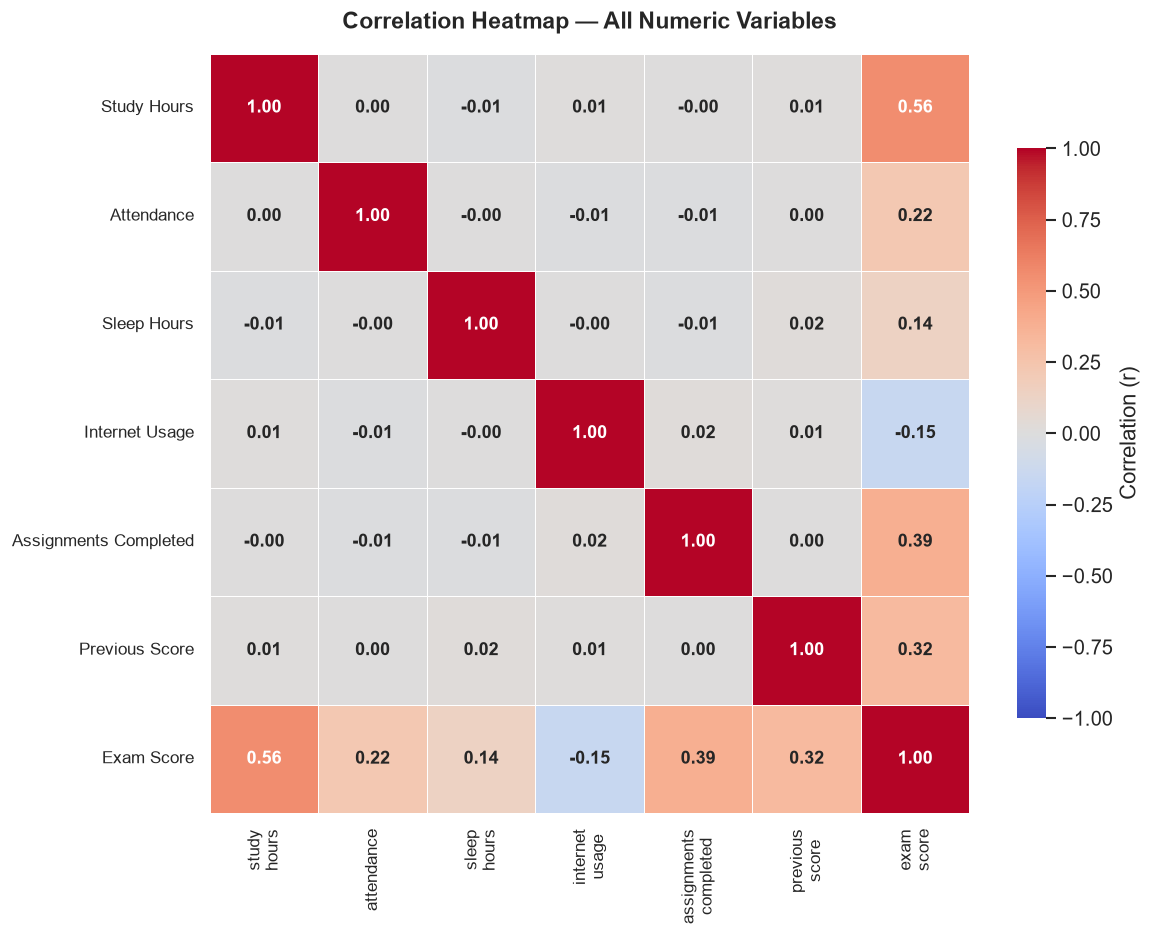

✅ Heatmap saved as chart_06_correlation_heatmap.png

💡 Key observations from heatmap:
   → exam_score row: study_hours (0.56) is the brightest blue
   → internet_usage row: only column with a negative (red) value vs exam_score
   → All other feature pairs: near white (0.00) — they are INDEPENDENT of each other!
     This is excellent — means each feature adds unique information.


In [36]:
corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.6,
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'shrink': 0.75, 'label': 'Correlation (r)'}
)

ax.set_title('Correlation Heatmap — All Numeric Variables', fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels([c.replace('_','\n') for c in numeric_cols], fontsize=10)
ax.set_yticklabels([c.replace('_',' ').title() for c in numeric_cols],
                   fontsize=10, rotation=0)

plt.tight_layout()
plt.savefig('../charts/chart_06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Heatmap saved as chart_06_correlation_heatmap.png')
print()
print('💡 Key observations from heatmap:')
print('   → exam_score row: study_hours (0.56) is the brightest blue')
print('   → internet_usage row: only column with a negative (red) value vs exam_score')
print('   → All other feature pairs: near white (0.00) — they are INDEPENDENT of each other!')
print('     This is excellent — means each feature adds unique information.')

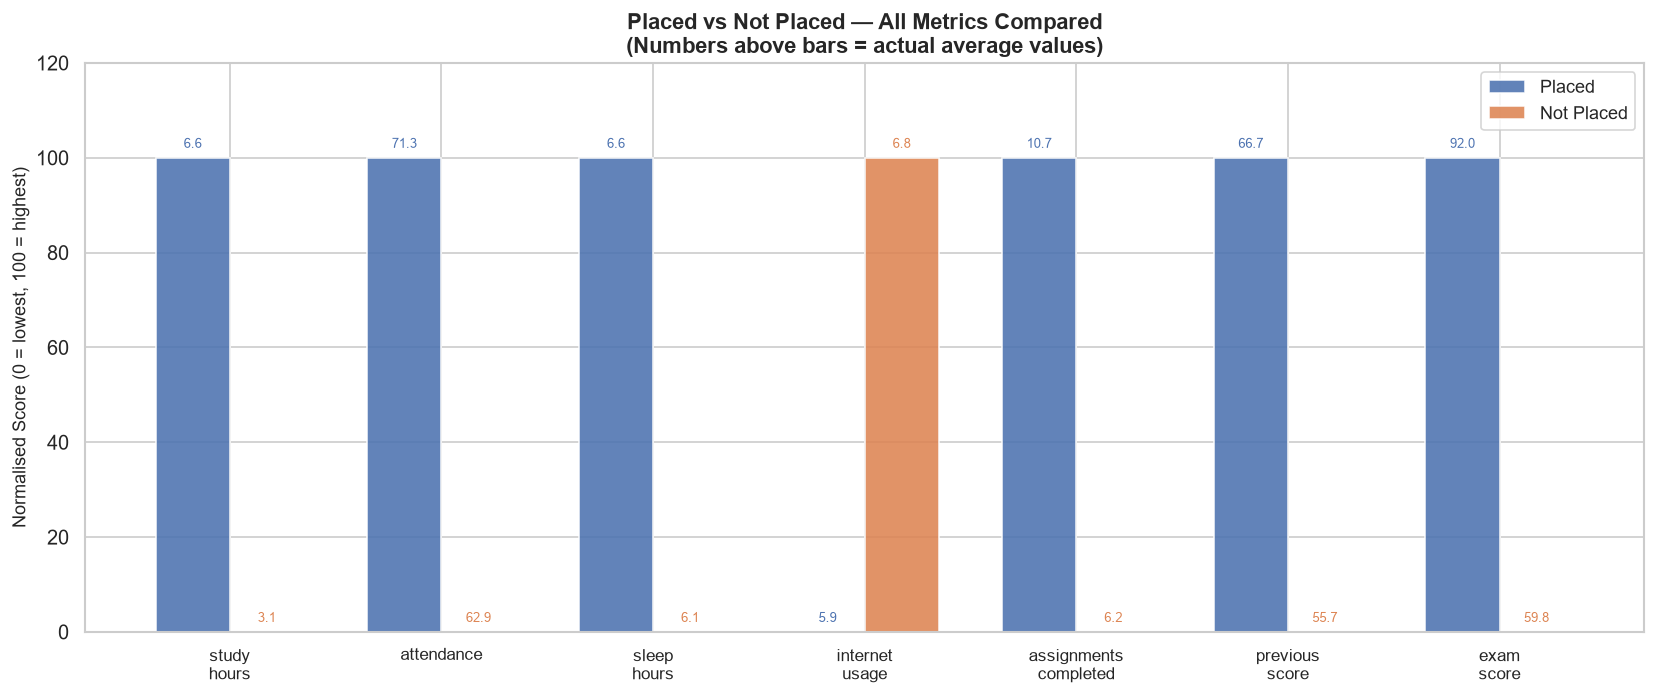

✅ Grouped bar chart saved as chart_07_placed_vs_notplaced.png


In [37]:
group_means = df.groupby('placement_status')[numeric_cols].mean()
group_norm = (group_means - group_means.min()) / \
             (group_means.max() - group_means.min()) * 100

fig, ax = plt.subplots(figsize=(14, 6))

x     = np.arange(len(numeric_cols))
width = 0.35

bars1 = ax.bar(x - width/2, group_norm.loc['Placed'],
               width, label='Placed',     color='#4C72B0', alpha=0.88)
bars2 = ax.bar(x + width/2, group_norm.loc['Not Placed'],
               width, label='Not Placed', color='#DD8452', alpha=0.88)
for bar, col in zip(bars1, numeric_cols):
    real_val = group_means.loc['Placed', col]
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{real_val:.1f}', ha='center', va='bottom', fontsize=8, color='#4C72B0')

for bar, col in zip(bars2, numeric_cols):
    real_val = group_means.loc['Not Placed', col]
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{real_val:.1f}', ha='center', va='bottom', fontsize=8, color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in numeric_cols], fontsize=10)
ax.set_ylabel('Normalised Score (0 = lowest, 100 = highest)', fontsize=11)
ax.set_title('Placed vs Not Placed — All Metrics Compared\n(Numbers above bars = actual average values)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 120)

plt.tight_layout()
plt.savefig('../charts/chart_07_placed_vs_notplaced.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Grouped bar chart saved as chart_07_placed_vs_notplaced.png')

In [46]:
print('=' * 65)
print('  STEP 4 — VISUAL ANALYSIS SUMMARY')
print('=' * 65)
print()
print('CHARTS PRODUCED:')
print('  chart_01_histograms.png         → Distribution of all 7 columns')
print('  chart_02_boxplots.png           → Placed vs Not Placed box plots')
print('  chart_03_placement_pie.png      → Placement ratio pie + bar')
print('  chart_04_scatter_plots.png      → 6 scatter plots vs exam_score')
print('  chart_05_study_vs_score.png     → Detailed study hours analysis')
print('  chart_06_correlation_heatmap.png→ Full correlation heatmap')
print('  chart_07_placed_vs_notplaced.png→ Grouped bar comparison')
print()
print('KEY VISUAL FINDINGS:')
print()
print('  1. HISTOGRAMS → exam_score is LEFT-skewed (most students score high)')
print('     All other columns are uniform / symmetric')
print()
print('  2. BOX PLOTS  → Placed students have clearly higher exam_score box')
print('     The two groups barely differ on sleep_hours')
print()
print('  3. SCATTER    → study_hours shows the clearest upward trend (r=+0.563)')
print('     internet_usage shows a slight downward trend (r=-0.152)')
print()
print('  4. HEATMAP    → All features are INDEPENDENT of each other (near 0)')
print('     Only exam_score shows meaningful correlations with features')
print()
print('  5. BAR CHART  → Placed students consistently outperform on every metric')
print('     Biggest gap: exam_score (+32 pts) and study_hours (+3.4 hrs/day)')
print()
print('=' * 65)


  STEP 4 — VISUAL ANALYSIS SUMMARY

CHARTS PRODUCED:
  chart_01_histograms.png         → Distribution of all 7 columns
  chart_02_boxplots.png           → Placed vs Not Placed box plots
  chart_03_placement_pie.png      → Placement ratio pie + bar
  chart_04_scatter_plots.png      → 6 scatter plots vs exam_score
  chart_05_study_vs_score.png     → Detailed study hours analysis
  chart_06_correlation_heatmap.png→ Full correlation heatmap
  chart_07_placed_vs_notplaced.png→ Grouped bar comparison

KEY VISUAL FINDINGS:

  1. HISTOGRAMS → exam_score is LEFT-skewed (most students score high)
     All other columns are uniform / symmetric

  2. BOX PLOTS  → Placed students have clearly higher exam_score box
     The two groups barely differ on sleep_hours

  3. SCATTER    → study_hours shows the clearest upward trend (r=+0.563)
     internet_usage shows a slight downward trend (r=-0.152)

  4. HEATMAP    → All features are INDEPENDENT of each other (near 0)
     Only exam_score shows meaning

In [39]:
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.titlesize']    = 13
PALETTE = {'Placed': '#4C72B0', 'Not Placed': '#DD8452'}
placed     = df[df['placement_status'] == 'Placed']
not_placed = df[df['placement_status'] == 'Not Placed']
print('✅ Setup complete. Starting insight extraction...')
print(f'   Total students : {len(df):,}')
print(f'   Placed         : {len(placed):,} (83.6%)')
print(f'   Not Placed     : {len(not_placed):,} (16.4%)')

✅ Setup complete. Starting insight extraction...
   Total students : 10,000
   Placed         : 8,356 (83.6%)
   Not Placed     : 1,644 (16.4%)


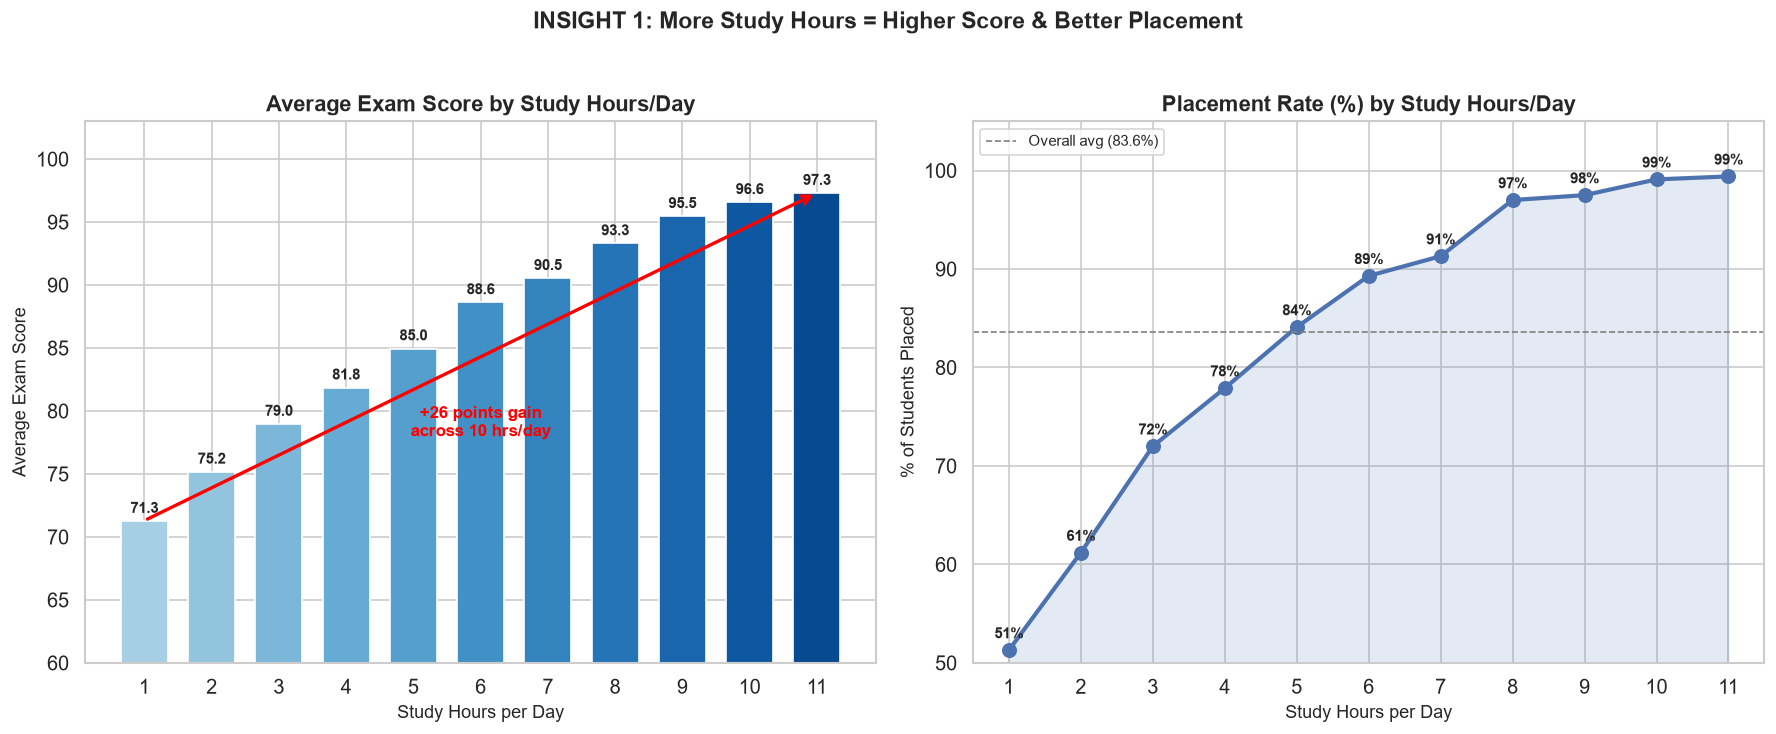

KEY NUMBERS:
   1 hrs/day → avg score = 71.3,  placement rate = 51%
   2 hrs/day → avg score = 75.2,  placement rate = 61%
   3 hrs/day → avg score = 79.0,  placement rate = 72%
   4 hrs/day → avg score = 81.8,  placement rate = 78%
   5 hrs/day → avg score = 85.0,  placement rate = 84%
   6 hrs/day → avg score = 88.6,  placement rate = 89%
   7 hrs/day → avg score = 90.5,  placement rate = 91%
   8 hrs/day → avg score = 93.3,  placement rate = 97%
   9 hrs/day → avg score = 95.5,  placement rate = 98%
  10 hrs/day → avg score = 96.6,  placement rate = 99%
  11 hrs/day → avg score = 97.3,  placement rate = 99%

 ACTION: Encourage students to study at least 7+ hrs/day.
   Students studying 7+ hrs have >90% placement rate.


In [40]:
avg_by_study = df.groupby('study_hours')['exam_score'].mean().round(2)
placement_by_study = df.groupby('study_hours')['placement_status'].apply(
    lambda x: (x == 'Placed').mean() * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax1 = axes[0]
colors_grad = plt.cm.Blues(np.linspace(0.35, 0.9, len(avg_by_study)))
bars = ax1.bar(avg_by_study.index, avg_by_study.values,
               color=colors_grad, edgecolor='white', width=0.7)
for bar, val in zip(bars, avg_by_study.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('Average Exam Score by Study Hours/Day')
ax1.set_xlabel('Study Hours per Day', fontsize=11)
ax1.set_ylabel('Average Exam Score', fontsize=11)
ax1.set_xticks(range(1, 12))
ax1.set_ylim(60, 103)
ax1.annotate('', xy=(11, 97.3), xytext=(1, 71.3),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax1.text(6, 78, '+26 points gain\nacross 10 hrs/day',
         color='red', fontsize=10, ha='center', fontweight='bold')
ax2 = axes[1]
ax2.plot(placement_by_study.index, placement_by_study.values,
         color='#4C72B0', linewidth=2.5, marker='o', markersize=8)
ax2.fill_between(placement_by_study.index, placement_by_study.values,
                 alpha=0.15, color='#4C72B0')

for x_val, y_val in zip(placement_by_study.index, placement_by_study.values):
    ax2.text(x_val, y_val + 1.2, f'{y_val:.0f}%',
             ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Placement Rate (%) by Study Hours/Day')
ax2.set_xlabel('Study Hours per Day', fontsize=11)
ax2.set_ylabel('% of Students Placed', fontsize=11)
ax2.set_xticks(range(1, 12))
ax2.set_ylim(50, 105)
ax2.axhline(83.6, color='grey', linestyle='--', linewidth=1, label='Overall avg (83.6%)')
ax2.legend(fontsize=9)

plt.suptitle('INSIGHT 1: More Study Hours = Higher Score & Better Placement',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../insights/insight_01_study_hours.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY NUMBERS:')
for hrs, score in avg_by_study.items():
    rate = placement_by_study[hrs]
    print(f'  {hrs:2d} hrs/day → avg score = {score:.1f},  placement rate = {rate:.0f}%')
print()
print(' ACTION: Encourage students to study at least 7+ hrs/day.')
print('   Students studying 7+ hrs have >90% placement rate.')

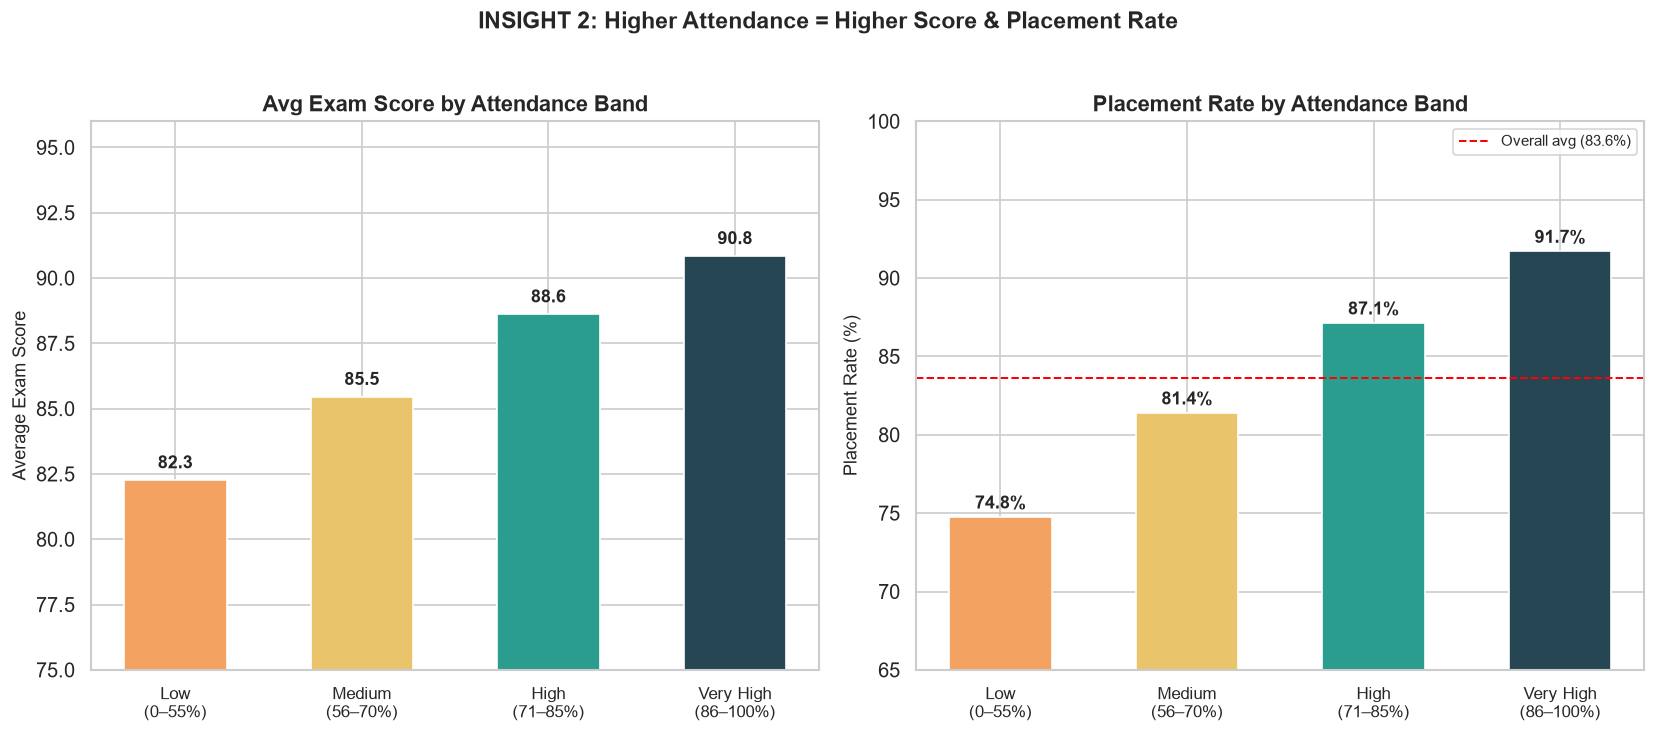

KEY NUMBERS:
                     avg_score  placed_rate  count
att_band                                          
Low (0–55%)              82.27        74.75   2634
Medium (56–70%)          85.46        81.39   2520
High (71–85%)            88.62        87.13   2363
Very High (86–100%)      90.85        91.70   2483

✅ ACTION: Target students with <55% attendance for intervention.
   Getting them to 70%+ could raise placement rate by ~7 percentage points.


In [41]:
df['att_band'] = pd.cut(df['attendance'],
    bins=[0, 55, 70, 85, 100],
    labels=['Low\n(0–55%)', 'Medium\n(56–70%)', 'High\n(71–85%)', 'Very High\n(86–100%)'])

att_stats = df.groupby('att_band', observed=True).agg(
    avg_score   = ('exam_score', 'mean'),
    placed_rate = ('placement_status', lambda x: (x == 'Placed').mean() * 100),
    count       = ('exam_score', 'count')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

band_colors = ['#f4a261', '#e9c46a', '#2a9d8f', '#264653']
x = np.arange(len(att_stats))
ax1 = axes[0]
bars = ax1.bar(x, att_stats['avg_score'], color=band_colors,
               edgecolor='white', width=0.55)
for bar, val in zip(bars, att_stats['avg_score']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(att_stats.index, fontsize=10)
ax1.set_ylabel('Average Exam Score', fontsize=11)
ax1.set_title('Avg Exam Score by Attendance Band')
ax1.set_ylim(75, 96)
ax2 = axes[1]
bars2 = ax2.bar(x, att_stats['placed_rate'], color=band_colors,
                edgecolor='white', width=0.55)
for bar, val in zip(bars2, att_stats['placed_rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(att_stats.index, fontsize=10)
ax2.set_ylabel('Placement Rate (%)', fontsize=11)
ax2.set_title('Placement Rate by Attendance Band')
ax2.set_ylim(65, 100)
ax2.axhline(83.6, color='red', linestyle='--', linewidth=1.2, label='Overall avg (83.6%)')
ax2.legend(fontsize=9)

plt.suptitle('INSIGHT 2: Higher Attendance = Higher Score & Placement Rate',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../insights/insight_02_attendance.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY NUMBERS:')
print(att_stats.rename(index=lambda x: str(x).replace('\n', ' ')).to_string())
print()
print('✅ ACTION: Target students with <55% attendance for intervention.')
print('   Getting them to 70%+ could raise placement rate by ~7 percentage points.')

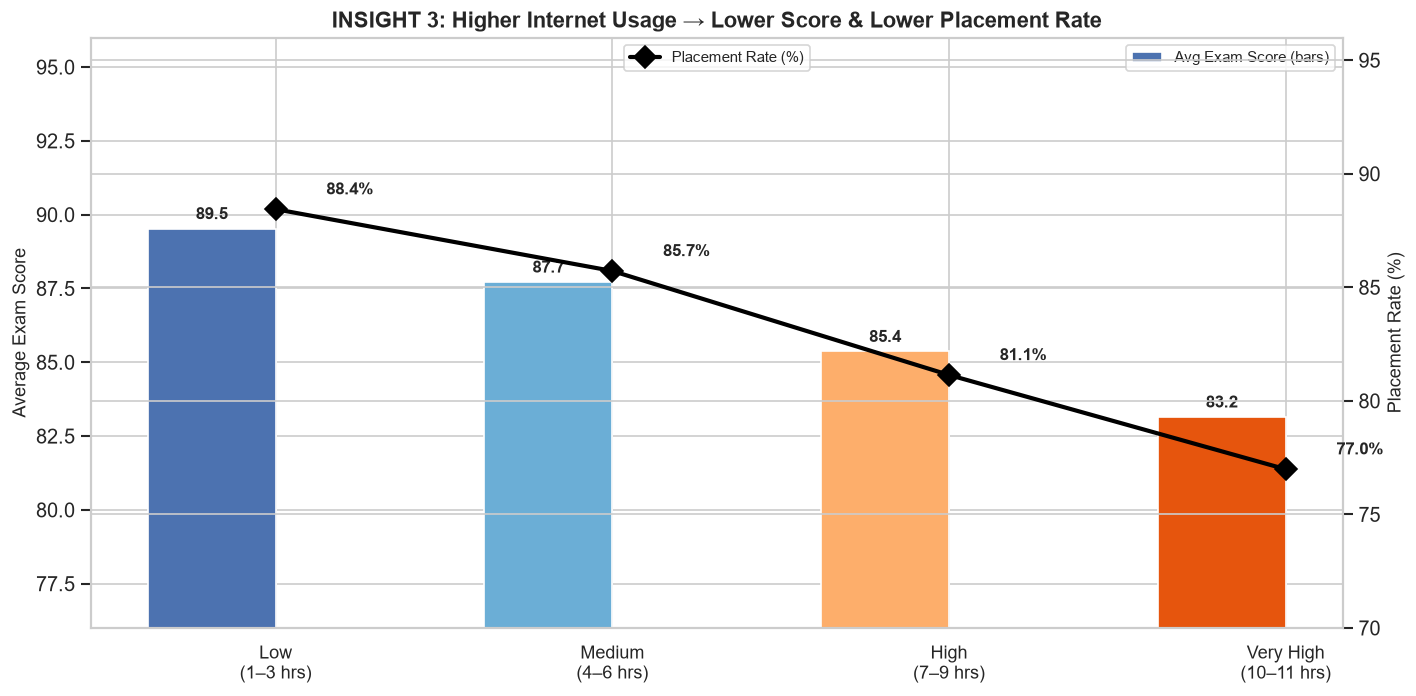

KEY NUMBERS:
                       avg_score  placed_rate  count
net_band                                            
Low (1–3 hrs)              89.53        88.44   2621
Medium (4–6 hrs)           87.72        85.72   2780
High (7–9 hrs)             85.37        81.14   2752
Very High (10–11 hrs)      83.15        76.99   1847

✅ ACTION: Encourage students to limit internet to under 4 hrs/day.
   Low-usage students score 6.4 points higher and place 11.4% more often.


In [42]:
df['net_band'] = pd.cut(df['internet_usage'],
    bins=[0, 3, 6, 9, 11],
    labels=['Low\n(1–3 hrs)', 'Medium\n(4–6 hrs)', 'High\n(7–9 hrs)', 'Very High\n(10–11 hrs)'])

net_stats = df.groupby('net_band', observed=True).agg(
    avg_score   = ('exam_score', 'mean'),
    placed_rate = ('placement_status', lambda x: (x == 'Placed').mean() * 100),
    count       = ('exam_score', 'count')
).round(2)

fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(net_stats))
width  = 0.38

colors = ['#4C72B0', '#6baed6', '#fdae6b', '#e6550d']

bars1 = ax.bar(x - width/2, net_stats['avg_score'],
               width, color=colors, edgecolor='white', label='Avg Exam Score')

ax2 = ax.twinx()
ax2.plot(x, net_stats['placed_rate'], color='black',
         linewidth=2.5, marker='D', markersize=9, label='Placement Rate (%)')

for bar, val in zip(bars1, net_stats['avg_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for xi, val in zip(x, net_stats['placed_rate']):
    ax2.text(xi + 0.22, val + 0.5, f'{val:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(net_stats.index, fontsize=11)
ax.set_ylabel('Average Exam Score', fontsize=11)
ax2.set_ylabel('Placement Rate (%)', fontsize=11)
ax.set_ylim(76, 96)
ax2.set_ylim(70, 96)
ax.set_title('INSIGHT 3: Higher Internet Usage → Lower Score & Lower Placement Rate',
             fontsize=13, fontweight='bold')

lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend([bars1], ['Avg Exam Score (bars)'], loc='upper right', fontsize=9)
ax2.legend(lines2, labels2, loc='upper center', fontsize=9)

plt.tight_layout()
plt.savefig('../insights/insight_03_internet_usage.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY NUMBERS:')
print(net_stats.rename(index=lambda x: str(x).replace('\n', ' ')).to_string())
print()
print('✅ ACTION: Encourage students to limit internet to under 4 hrs/day.')
print('   Low-usage students score 6.4 points higher and place 11.4% more often.')

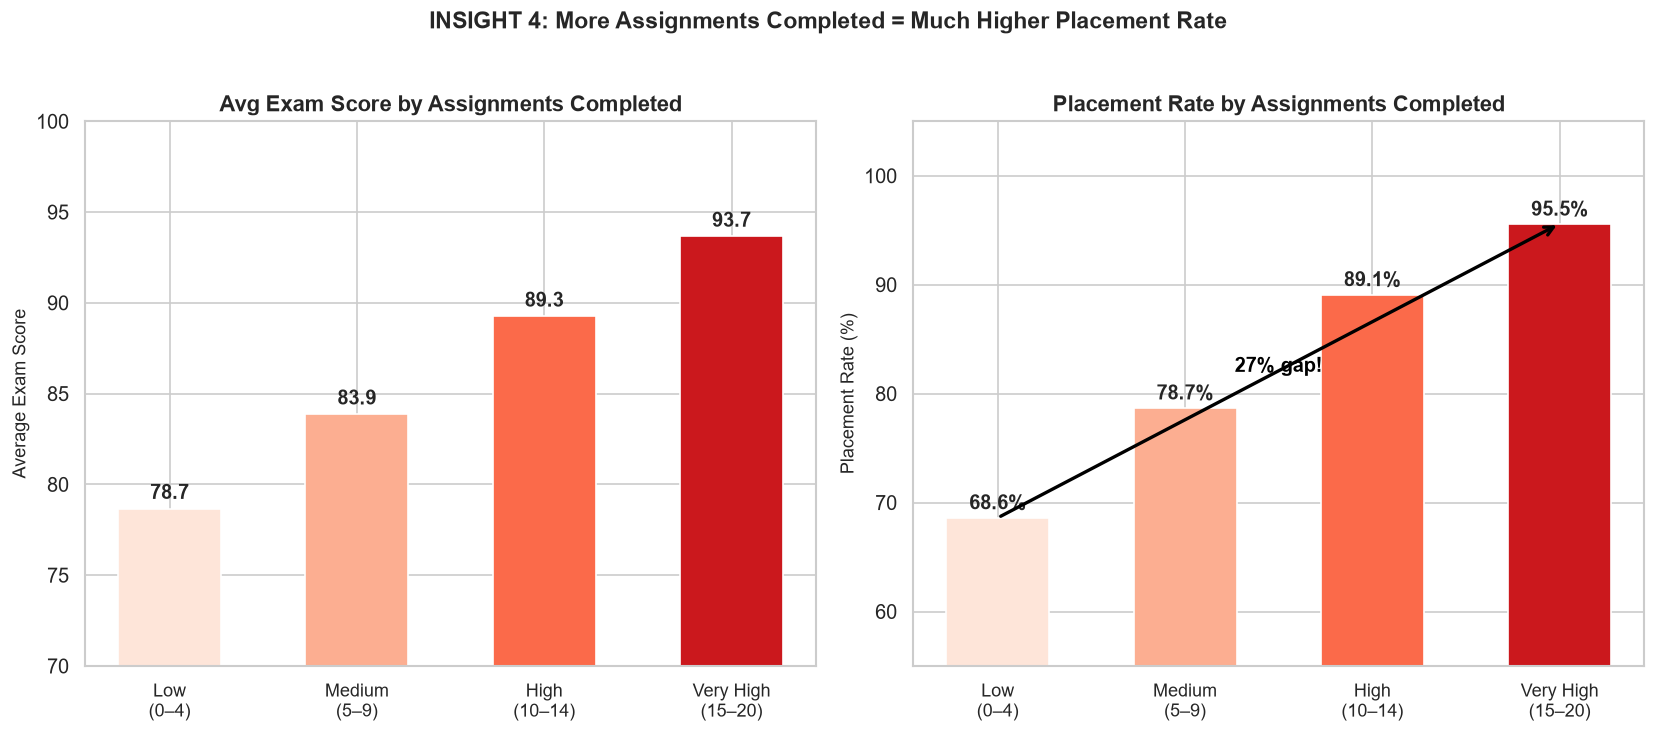

KEY NUMBERS:
                   avg_score  placed_rate  count
assign_band                                     
Low (0–4)              78.67        68.60   2328
Medium (5–9)           83.87        78.68   2495
High (10–14)           89.26        89.08   2325
Very High (15–20)      93.66        95.55   2852

✅ ACTION: Make assignment completion a priority metric.
   Students completing 15+ assignments have 95.6% placement rate!


In [43]:
df['assign_band'] = pd.cut(df['assignments_completed'],
    bins=[-1, 4, 9, 14, 20],
    labels=['Low\n(0–4)', 'Medium\n(5–9)', 'High\n(10–14)', 'Very High\n(15–20)'])

assign_stats = df.groupby('assign_band', observed=True).agg(
    avg_score   = ('exam_score', 'mean'),
    placed_rate = ('placement_status', lambda x: (x == 'Placed').mean() * 100),
    count       = ('exam_score', 'count')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x      = np.arange(len(assign_stats))
colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#cb181d']


ax1 = axes[0]
bars = ax1.bar(x, assign_stats['avg_score'], color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, assign_stats['avg_score']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(assign_stats.index, fontsize=11)
ax1.set_ylabel('Average Exam Score', fontsize=11)
ax1.set_title('Avg Exam Score by Assignments Completed')
ax1.set_ylim(70, 100)
ax2 = axes[1]
bars2 = ax2.bar(x, assign_stats['placed_rate'], color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars2, assign_stats['placed_rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(assign_stats.index, fontsize=11)
ax2.set_ylabel('Placement Rate (%)', fontsize=11)
ax2.set_title('Placement Rate by Assignments Completed')
ax2.set_ylim(55, 105)


ax2.annotate('', xy=(3, 95.6), xytext=(0, 68.6),
             arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax2.text(1.5, 82, '27% gap!', fontsize=12,
         color='black', fontweight='bold', ha='center')

plt.suptitle('INSIGHT 4: More Assignments Completed = Much Higher Placement Rate',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../insights/insight_04_assignments.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY NUMBERS:')
print(assign_stats.rename(index=lambda x: str(x).replace('\n', ' ')).to_string())
print()
print('✅ ACTION: Make assignment completion a priority metric.')
print('   Students completing 15+ assignments have 95.6% placement rate!')

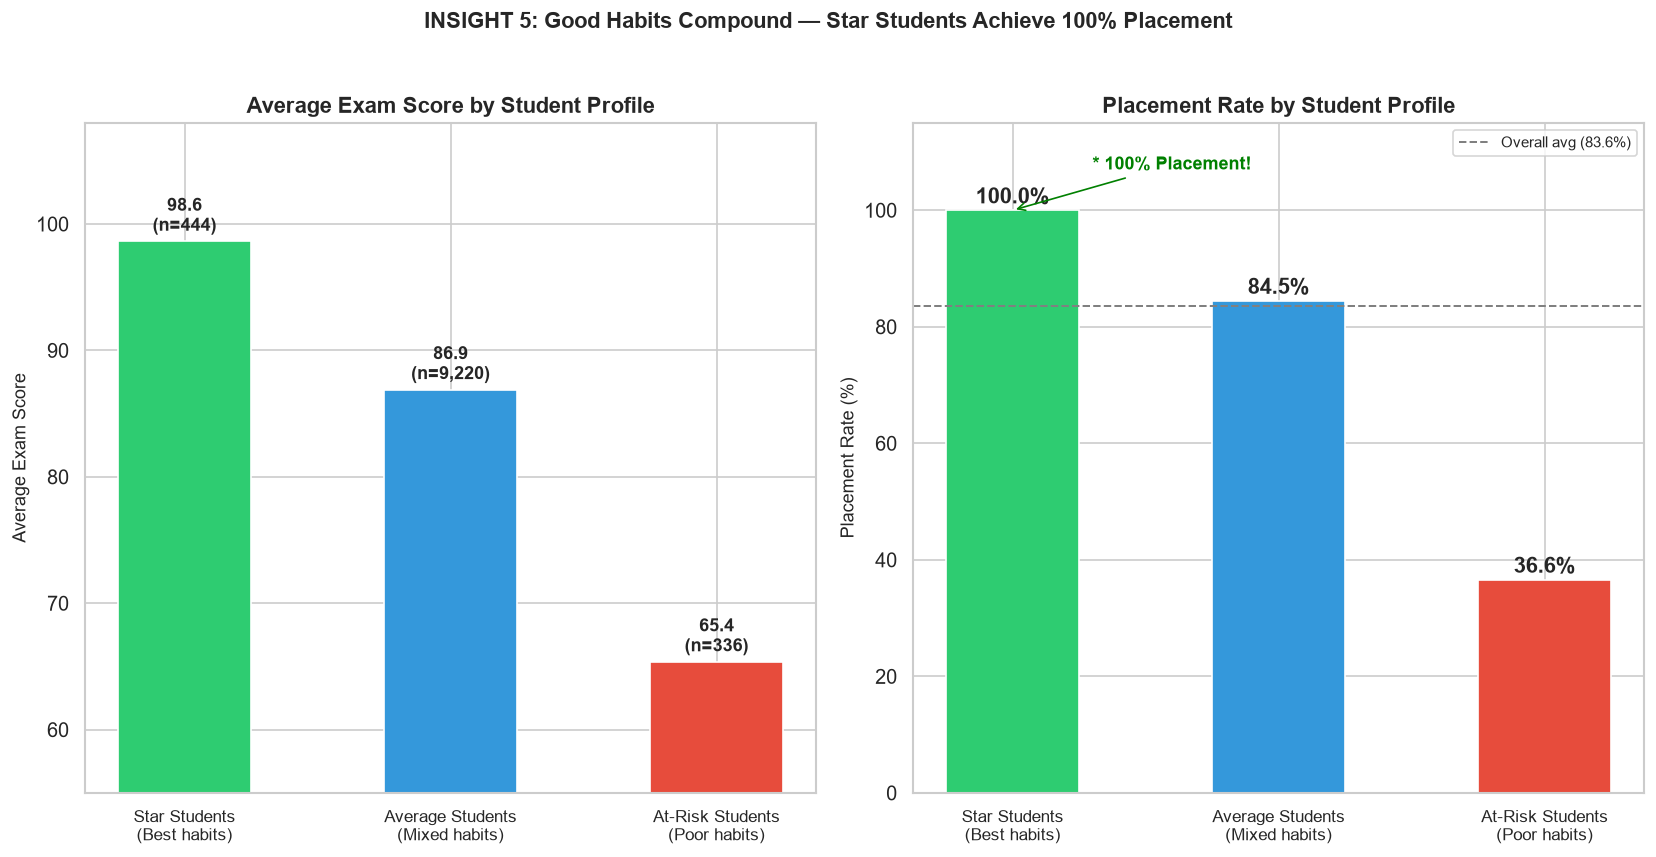

KEY NUMBERS:
  Star Students (Best habits)              n=444  avg score=98.6  placement=100.0%
  Average Students (Mixed habits)          n=9,220  avg score=86.9  placement=84.5%
  At-Risk Students (Poor habits)           n=336  avg score=65.4  placement=36.6%



In [44]:
star_students = df[
    (df['study_hours']    >= 8) &
    (df['attendance']     >= 80) &
    (df['internet_usage'] <= 4)
]
at_risk_students = df[
    (df['study_hours']    <= 3) &
    (df['attendance']     <= 60) &
    (df['internet_usage'] >= 8)
]
rest = df[
    ~df.index.isin(star_students.index) &
    ~df.index.isin(at_risk_students.index)
]
groups = {
    'Star Students\n(Best habits)' : star_students,
    'Average Students\n(Mixed habits)': rest,
    'At-Risk Students\n(Poor habits)' : at_risk_students
}

labels, scores, rates, counts = [], [], [], []
for label, grp in groups.items():
    labels.append(label)
    scores.append(grp['exam_score'].mean())
    rates.append((grp['placement_status'] == 'Placed').mean() * 100)
    counts.append(len(grp))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
group_colors = ['#2ecc71', '#3498db', '#e74c3c']
x = np.arange(3)
ax1 = axes[0]
bars = ax1.bar(x, scores, color=group_colors, edgecolor='white', width=0.5)
for bar, val, cnt in zip(bars, scores, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{val:.1f}\n(n={cnt:,})', ha='center', va='bottom',
             fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylabel('Average Exam Score', fontsize=11)
ax1.set_title('Average Exam Score by Student Profile')
ax1.set_ylim(55, 108)
ax2 = axes[1]
bars2 = ax2.bar(x, rates, color=group_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylabel('Placement Rate (%)', fontsize=11)
ax2.set_title('Placement Rate by Student Profile')
ax2.set_ylim(0, 115)
ax2.axhline(83.6, color='grey', linestyle='--', linewidth=1.2, label='Overall avg (83.6%)')
ax2.legend(fontsize=9)
ax2.annotate('* 100% Placement!', xy=(0, 100), xytext=(0.3, 107),
             fontsize=11, color='green', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='green'))

plt.suptitle('INSIGHT 5: Good Habits Compound — Star Students Achieve 100% Placement',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../insights/insight_05_student_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY NUMBERS:')
for label, score, rate, cnt in zip(labels, scores, rates, counts):
    clean_label = label.replace('\n', ' ')
    print(f'  {clean_label:<40} n={cnt:,}  avg score={score:.1f}  placement={rate:.1f}%')
print()

In [45]:
print('=' * 68)
print('   FINAL INSIGHT REPORT — STUDENT PERFORMANCE DATASET')
print('   ReadyNest Corp  |  Week 1 Task  |  10,000 Students')
print('=' * 68)
print()
print('INSIGHT 1 — STUDY HOURS IS THE #1 PREDICTOR (r = +0.563)')
print('  Every extra hour of daily study raises exam score by ~2.6 points.')
print('  Students studying 1 hr/day avg 71.3 vs 97.3 for 11 hrs/day.')
print('  ACTION: Push minimum study hours to 7+/day for >90% placement.')
print()
print('INSIGHT 2 — ATTENDANCE DRIVES PLACEMENT RATE')
print('  Very High attendance (86-100%): 91.7% placement rate, avg score 90.85')
print('  Low attendance    (0-55%):      74.8% placement rate, avg score 82.27')
print('  GAP: 17 percentage points in placement rate.')
print('  ACTION: Flag students below 55% attendance for immediate support.')
print()
print('INSIGHT 3 — INTERNET USAGE HAS A NEGATIVE EFFECT (r = -0.152)')
print('  Low usage (1-3 hrs): avg score 89.53, placement 88.4%')
print('  High usage (10-11 hrs): avg score 83.15, placement 77.0%')
print('  GAP: 6.4 points in exam score, 11.4% in placement rate.')
print('  ACTION: Awareness campaigns on healthy internet usage limits.')
print()
print('INSIGHT 4 — ASSIGNMENT COMPLETION = NEAR-GUARANTEED PLACEMENT')
print('  15-20 assignments: 95.6% placement rate, avg score 93.66')
print('   0-4  assignments: 68.6% placement rate, avg score 78.67')
print('  GAP: 27 percentage points — the biggest gap of all insights!')
print('  ACTION: Make assignment submission tracking a priority metric.')
print()
print('INSIGHT 5 — GOOD HABITS COMPOUND: 100% PLACEMENT IS ACHIEVABLE')
print('  Star profile (study≥8, attend≥80%, internet≤4 hrs):')
print('    → 444 students, 100.0% placed, avg score 98.64')
print('  At-risk profile (study≤3, attend≤60%, internet≥8 hrs):')
print('    → 336 students, 36.6% placed, avg score 65.38')
print('  GAP: 63.4 percentage points in placement rate!')
print('  ACTION: Use these 3 metrics as an early warning system.')
print()
print('=' * 68)

   FINAL INSIGHT REPORT — STUDENT PERFORMANCE DATASET
   ReadyNest Corp  |  Week 1 Task  |  10,000 Students

INSIGHT 1 — STUDY HOURS IS THE #1 PREDICTOR (r = +0.563)
  Every extra hour of daily study raises exam score by ~2.6 points.
  Students studying 1 hr/day avg 71.3 vs 97.3 for 11 hrs/day.
  ACTION: Push minimum study hours to 7+/day for >90% placement.

INSIGHT 2 — ATTENDANCE DRIVES PLACEMENT RATE
  Very High attendance (86-100%): 91.7% placement rate, avg score 90.85
  Low attendance    (0-55%):      74.8% placement rate, avg score 82.27
  GAP: 17 percentage points in placement rate.
  ACTION: Flag students below 55% attendance for immediate support.

INSIGHT 3 — INTERNET USAGE HAS A NEGATIVE EFFECT (r = -0.152)
  Low usage (1-3 hrs): avg score 89.53, placement 88.4%
  High usage (10-11 hrs): avg score 83.15, placement 77.0%
  GAP: 6.4 points in exam score, 11.4% in placement rate.
  ACTION: Awareness campaigns on healthy internet usage limits.

INSIGHT 4 — ASSIGNMENT COMPLETION